In [12]:
import torch
import torch.nn as nn
import hdbscan
from sklearn.metrics import silhouette_score, adjusted_rand_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.decomposition import PCA
import os
import sys
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, PROJECT_ROOT)
from sklearn.metrics import davies_bouldin_score

from src.data.load_cifar100 import get_cifar100_loaders, create_and_load_subset
from src.models.autoencoder import Autoencoder
from src.data.load_cifar10 import get_cifar10_loaders
from src.models.cmae import CMAE
from src.models.masked_autoencoder import  MAE
from sklearn.manifold import TSNE
import torch.nn.functional as F
from sklearn.preprocessing import normalize

# Load pretrained model

In [13]:
def load_trained_model(model_path, model_type='autoencoder'):
    """
    Wczytanie wytrenowanego modelu

    Args:
        model_path: Ścieżka do pliku .pt
         model_type: "autoencoder', 'cmae' lub 'mae'

    Returns:
        model, checkpoint (słownik z metadanymi)
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Nie znaleziono pliku: {model_path}")

    # wczytanie checkpointa
    checkpoint = torch.load(model_path, map_location=device)

    # ładowanie modelu
    latent_dim = checkpoint.get('latent_dim', 256)  # domyślnie 256
    if model_type.lower() == 'cmae':
        model = CMAE(latent_dim=latent_dim).to(device)
    elif model_type.lower() == 'mae':
        model = MAE(latent_dim=latent_dim).to(device)
    elif model_type.lower() == 'autoencoder':
        model = Autoencoder(latent_dim=latent_dim).to(device)
    else:
        raise ValueError("model_type musi być: 'cmae', 'mae' lub 'autoencoder'")

    # ładowanie wag
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    print(f"Model załadowany")
    print(f"Epoka: {checkpoint['epoch']}")
    print(f"Train Loss: {checkpoint['train_loss']:.6f}")
    print(f"Val Loss: {checkpoint['val_loss']:.6f}")
    print(f"Latent Dim: {latent_dim}\n")

    return model, checkpoint

# Ekstrakcja cech

In [14]:
def extract_features(model, dataloader):
    """
    Wyciąga wektory cech z encodera

    Args:
        model: Autoencoder, MAE lub CMAE
        dataloader: DataLoader z danymi

    Returns:
        features: numpy array [N, latent_dim]
        labels: numpy array [N]
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    all_features = []
    all_labels = []

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(dataloader):
            images = images.to(device)

            if hasattr(model, 'online_encoder'):
                # CMAE
                features = model.online_encoder(images)
            
            elif hasattr(model, 'encoder'):
                # MAE oraz Autoencoder (oba mają self.encoder)
                features = model.encoder(images)
            
            else:
                raise AttributeError("Model nie ma atrybutu 'encoder' ani 'online_encoder'")


            # flattenujemy cechy -- [B, D, 1, 1] -> [B, D]
            if len(features.size()) > 2:
                features = features.view(features.size(0), -1)
            # dostajemy tylko cechy
            # features = model.encode(images)  # [batch_size, latent_dim]
            if batch_idx == 0:  # sprawdzenie
                print(f"Features: {features.size()}")

            all_features.append(features.cpu().numpy())
            all_labels.append(labels.numpy())


    features = np.concatenate(all_features, axis=0)
    labels = np.concatenate(all_labels, axis=0) # do ocenienia klasteryzacji


    print(f"Wyciągnięto cechy: {features.shape}")
    # print(f"Klasy {labels[:5]}") #sprawdzenie

    return features, labels

# Klasteryzacja

In [15]:
def clustering(features, labels, n_clusters=10, pca_dim=50):
    """
    Klasteryzacja używając K-means i HDBSCAN
    
    Args:
        features: numpy array [N, latent_dim]
        labels: numpy array [N] - prawdziwe etykiety
        n_clusters: liczba klastrów dla K-means
    
    Returns:
        cluster_ids: numpy array [N] - przypisanie do klastrów (K-means)
        kmeans: obiekt KMeans
        metrics: słownik z metrykami K-means
        metrics_hdb: słownik z metrykami HDBSCAN
    """

    # normalizacja wektora cech
    features_normalized = normalize(features,norm='l2')

    # zmniejszenie wymiarowości cech do 50 z 256
    if features_normalized.shape[1] > pca_dim:
        pca = PCA(n_components=pca_dim, random_state=42)
        features_reduced = pca.fit_transform(features_normalized)
    else:
        features_reduced = features_normalized


    # # HDBSCAN
    # clusterer = hdbscan.HDBSCAN(
    #     min_cluster_size=n_clusters,
    #     min_samples=5,
    #     cluster_selection_method='eom',
    #     allow_single_cluster=True,
    #     metric='euclidean',
    #     algorithm='best',
    #     leaf_size=30
    # )
    # cluster_ids_hdb = clusterer.fit_predict(features_reduced)
    #


    # K-means
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10, verbose=0)
    cluster_ids = kmeans.fit_predict(features_reduced)
    
    # Metryki K-means
    nmi = normalized_mutual_info_score(labels, cluster_ids)
    ari = adjusted_rand_score(labels, cluster_ids)
    silhouette = silhouette_score(features, cluster_ids)
    dbi = davies_bouldin_score(features, cluster_ids)

    
    metrics = {
        'nmi': nmi,
        'ari': ari,
        'silhouette': silhouette,
        'dbi' : dbi,
        'n_clusters': n_clusters,
        'inertia': kmeans.inertia_
    }
    
    print("=== K-means ===")
    print(f"NMI (Normalized Mutual Information): {nmi:.4f}")
    print(f"ARI (Adjusted Rand Index): {ari:.4f}")
    print(f"DBI {dbi:.4f}")

    print(f"Silhouette: {silhouette:.4f}")
    print(f"Inertia: {kmeans.inertia_:.2f}\n")
    
    # # Metryki HDBSCAN
    # nmi_hdb = normalized_mutual_info_score(labels, cluster_ids_hdb)
    # ari_hdb = adjusted_rand_score(labels, cluster_ids_hdb)
    # n_clusters_hdb = len(set(cluster_ids_hdb)) - (1 if -1 in cluster_ids_hdb else 0)
    # n_noise = list(cluster_ids_hdb).count(-1)
    # 
    # metrics_hdb = {
    #     'nmi': nmi_hdb,
    #     'ari': ari_hdb,
    #     'n_clusters': n_clusters_hdb,
    #     'n_noise': n_noise
    # }
    # 
    # print(f"NMI (Normalized Mutual Information): {nmi_hdb:.4f}")
    # print(f"ARI (Adjusted Rand Index): {ari_hdb:.4f}")
    # print(f"Liczba znalezionych klastrów: {n_clusters_hdb}")
    # print(f"Liczba punktów noise: {n_noise}\n")
    
    return cluster_ids, kmeans, metrics

# Wizualizacja klastrów

In [16]:
def visualize_clusters(features, cluster_ids, labels, save_path):
    """
    Pokazanie klastrow w 2D (PCA)
    """

    pca = PCA(n_components=2, random_state=42)
    features_2d = pca.fit_transform(features)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    # klastry k-means
    scatter1 = ax1.scatter(features_2d[:, 0], features_2d[:, 1],
                          c=cluster_ids, cmap='tab10', alpha=0.6, s=3)
    ax1.set_title('K-means Clusters', fontsize=14, fontweight='bold')
    plt.colorbar(scatter1, ax=ax1, label='Cluster ID')

    # etykeity z datasetu

    scatter2 = ax2.scatter(features_2d[:, 0], features_2d[:, 1],
                          c=labels, cmap='tab10', alpha=0.6, s=3)
    ax2.set_title('True Labels', fontsize=14, fontweight='bold')
    plt.colorbar(scatter2, ax=ax2, label='Class ID')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    plt.close()



def visualize_clusters_tsne(features, cluster_labels, true_labels, save_path=None):
    """
    Wizualizacja klastrów za pomocą t-SNE
    """

    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    features_2d = tsne.fit_transform(features)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Wizualizacja z przypisaniami z K-Means
    scatter1 = axes[0].scatter(features_2d[:, 0], features_2d[:, 1],
                               c=cluster_labels, cmap='tab10', s=5, alpha=0.6)
    axes[0].set_title('K-Means Cluster Assignments')
    axes[0].set_xlabel('t-SNE Component 1')
    axes[0].set_ylabel('t-SNE Component 2')
    plt.colorbar(scatter1, ax=axes[0])

    # Wizualizacja z prawdziwymi etykietami
    scatter2 = axes[1].scatter(features_2d[:, 0], features_2d[:, 1],
                               c=true_labels, cmap='tab10', s=5, alpha=0.6)
    axes[1].set_title('True Class Labels')
    axes[1].set_xlabel('t-SNE Component 1')
    axes[1].set_ylabel('t-SNE Component 2')
    plt.colorbar(scatter2, ax=axes[1])

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# Sprawdzenie składu klastrów

In [17]:
def analyze_cluster_composition(cluster_ids, labels, n_clusters=100):
    """
    Pokazuje, które klasy CIFAR są w których klastrach
    """

    for cluster_id in range(min(10, n_clusters)):  # pokaż pierwsze 10
        mask = cluster_ids == cluster_id
        cluster_labels = labels[mask]

        print(f"Klaster {cluster_id} (rozmiar: {len(cluster_labels)}):")

        unique, counts = np.unique(cluster_labels, return_counts=True)
        sorted_indices = np.argsort(-counts)[:5]  # top 5

        for idx in sorted_indices:
            label = unique[idx]
            count = counts[idx]
            percentage = 100 * count / len(cluster_labels)
            print(f"  Klasa {label:2d}: {count:3d} obrazów ({percentage:5.1f}%)")
        print()

#  Wizualizacja przykładów z klastrów

In [18]:
def visualize_cluster_samples(cluster_ids, test_loader, cluster_id=0, n_samples=25):


    all_images = []
    for images, _ in test_loader:
        all_images.append(images)
    all_images = torch.cat(all_images, dim=0)

    # znajdywanie obrazów z danego klastra
    mask = cluster_ids == cluster_id
    cluster_images = all_images[mask][:n_samples]

    fig, axes = plt.subplots(5, 5, figsize=(10, 10))
    for idx, ax in enumerate(axes.flat):
        if idx < len(cluster_images):
            img = cluster_images[idx].permute(1, 2, 0).numpy()
            ax.imshow(img)
        ax.axis('off')
    plt.suptitle(f'Przykładowe obrazy z klastra {cluster_id}')
    plt.tight_layout()
    plt.show()


# Czystość klastrów -- sprawdzenie, jaki % stanowi najczęstsza klasa w danym klastrze

In [19]:
def cluster_purity(cluster_ids, labels):

    n_clusters = len(np.unique(cluster_ids))
    purities = []

    for cluster_id in range(n_clusters):
        mask = cluster_ids == cluster_id
        cluster_labels = labels[mask]

        if len(cluster_labels) > 0:
            # Najczęstsza klasa w tym klastrze
            most_common = np.bincount(cluster_labels).max()
            purity = most_common / len(cluster_labels)
            purities.append(purity)

    avg_purity = np.mean(purities)
    print(f"Średnia czystość klastrów: {avg_purity:.4f}")
    return avg_purity

# Zapis wyników klasteryzacji do csv

In [20]:

def save_results_to_csv(cluster_ids, labels, metrics, save_dir):
    # opisanie każdego obrazu
    results_df = pd.DataFrame({
        'image_id': range(len(labels)),
        'true_label': labels,
        'cluster_id': cluster_ids,
        'correct_cluster': (labels == cluster_ids).astype(int)  # czy zgadza się
    })
    results_csv = os.path.join(save_dir, 'clustering_results.csv')
    results_df.to_csv(results_csv, index=False)


    summary_df = pd.DataFrame({
        'metric': ['NMI', 'ARI', 'n_clusters', 'inertia','n_samples'],
        'value': [
            f"{metrics['nmi']:.6f}",
            f"{metrics['ari']:.6f}",
            metrics['n_clusters'],
            f"{metrics['inertia']:.2f}",
            len(labels)
        ]
    })


    return results_df, summary_df

# Ekstrakcja i klasteryzacja dla autoenkodera i cifar10

In [ ]:
# ładowanie modelu
model_path= '../training_results/autoencoder/cifar10/autoencoder_cifar10_best_20260107_180431.pt'
model, checkpoint = load_trained_model(model_path, model_type='autoencoder')
# print(model)
# print(checkpoint)


selected_classes = checkpoint.get('selected_classes', None)
# print(model)
# print(checkpoint)



batch_size = 64

# ładowanie danych testowych dla wszyskicj klas
# n_clusters = 10
# _, _, test_loader = get_cifar10_loaders(batch_size=batch_size)

# ładowanie danych testowych dla wybranej liczby klas
n_clusters = len(selected_classes)
print(n_clusters)
_, _, _, _, test_loader = create_and_load_subset(2, batch_size=batch_size, selected_classes=selected_classes)

# wyciąganie cech
features, labels = extract_features(model, test_loader)

# klasteryzacja
cluster_ids, kmeans, metrics, metrics_hdb = clustering(features, labels, n_clusters)

# zapis wynikow
BASE_DIR = os.getcwd()
save_dir = os.path.join(BASE_DIR, '../..', 'experiments', 'autoencoder','cifar10')
os.makedirs(save_dir, exist_ok=True)
results_df, summary_df = save_results_to_csv(cluster_ids, labels, metrics, save_dir)

# wizualizacja
vis_path = os.path.join(save_dir, 'clusters_visualization.png')
visualize_clusters(features, cluster_ids, labels, vis_path)


tsne_path = os.path.join(save_dir, 'clusters_tsne_visualization.png')
visualize_clusters_tsne(features, cluster_ids, labels, tsne_path)
analyze_cluster_composition(cluster_ids, labels, n_clusters)
visualize_cluster_samples(cluster_ids, test_loader, cluster_id=0, n_samples=25)
cluster_purity(cluster_ids, labels)



#  Ekstrakcja i klasteryzacja dla autoenkodera i cifar100

In [ ]:
# ładowanie modelu
model_path= '../training_results/autoencoder/cifar100/autoencoder_cifar100_best_20260107_170204.pt'
model, checkpoint = load_trained_model(model_path, model_type='autoencoder')
# print(model)
# print(checkpoint)

selected_classes = checkpoint.get('selected_classes', None)


# ładowanie danych testowych
batch_size = 64
_, _, test_loader = get_cifar100_loaders(batch_size=batch_size)
# print(f"Obrazów testowych: {len(test_loader)}")
# for batch_idx, (image, _) in enumerate(test_loader):
#     print(f"Batch {batch_idx} / {len(test_loader)}")


# wyciąganie cech
features, labels = extract_features(model, test_loader)

# klasteryzacja
n_clusters = 100
cluster_ids, kmeans, metrics = clustering(features, labels, n_clusters)

# zapis wynikow
BASE_DIR = os.getcwd()
save_dir = os.path.join(BASE_DIR, '../..', 'experiments', 'autoencoder','cifar100')
os.makedirs(save_dir, exist_ok=True)
results_df, summary_df = save_results_to_csv(cluster_ids, labels, metrics, save_dir)

# wizualizacja
vis_path = os.path.join(save_dir, 'clusters_visualization.png')
visualize_clusters(features, cluster_ids, labels, vis_path)



tsne_path = os.path.join(save_dir, 'clusters_tsne_visualization.png')
visualize_clusters_tsne(features, cluster_ids, labels, tsne_path)
analyze_cluster_composition(cluster_ids, labels, n_clusters)
visualize_cluster_samples(cluster_ids, test_loader, cluster_id=0, n_samples=25)
cluster_purity(cluster_ids, labels)



In [ ]:
# ładowanie modelu
model_path= '../training_results/autoencoder/cifar100/autoencoder_cifar100_best_20260112_234254.pt'
model, checkpoint = load_trained_model(model_path, model_type='autoencoder')
# print(model)
# print(checkpoint)

selected_classes = checkpoint.get('selected_classes', None)
# print(model)
# print(checkpoint)


# ładowanie danych testowych dla wszyskicj klas
# n_clusters = 10
# _, _, test_loader = get_cifar10_loaders(batch_size=batch_size)

# ładowanie danych testowych dla wybranej liczby klas
n_clusters = len(selected_classes)
print(n_clusters)
_, _, _, _, test_loader = create_and_load_subset(2, batch_size=batch_size, selected_classes=selected_classes)

# print(f"Obrazów testowych: {len(test_loader)}")
# for batch_idx, (image, _) in enumerate(test_loader):
#     print(f"Batch {batch_idx} / {len(test_loader)}")


# wyciąganie cech
features, labels = extract_features(model, test_loader)

# klasteryzacja
cluster_ids, kmeans, metrics = clustering(features, labels, n_clusters)

# zapis wynikow
BASE_DIR = os.getcwd()
save_dir = os.path.join(BASE_DIR, '../..', 'experiments', 'autoencoder','cifar100', f'n_clasters_{n_clusters}')
os.makedirs(save_dir, exist_ok=True)
results_df, summary_df = save_results_to_csv(cluster_ids, labels, metrics, save_dir)

# wizualizacja
vis_path = os.path.join(save_dir, 'clusters_visualization.png')
visualize_clusters(features, cluster_ids, labels, vis_path)




tsne_path = os.path.join(save_dir, 'clusters_tsne_visualization.png')
visualize_clusters_tsne(features, cluster_ids, labels, tsne_path)
analyze_cluster_composition(cluster_ids, labels, n_clusters)
visualize_cluster_samples(cluster_ids, test_loader, cluster_id=0, n_samples=25)
cluster_purity(cluster_ids, labels)



#  Ekstrakcja i klasteryzacja dla MAE i cifar10

Model załadowany
Epoka: 41
Train Loss: 0.066288
Val Loss: 0.065836
Latent Dim: 256

Features: torch.Size([64, 256])
Wyciągnięto cechy: (10000, 256)
NMI (Normalized Mutual Information): 0.0705
ARI (Adjusted Rand Index): 0.0359
Inertia: 33781.43



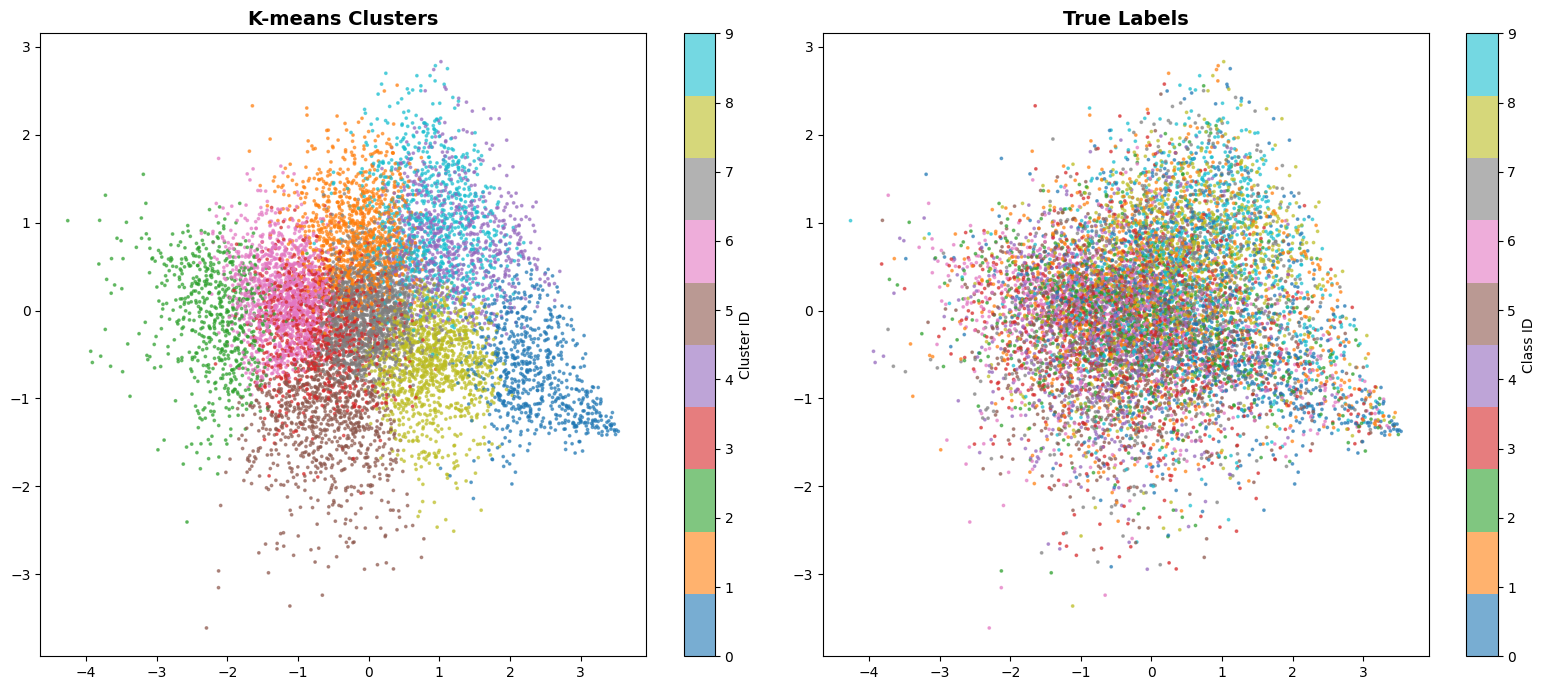

In [35]:
# ładowanie modelu
model_path= '../training_results/masked_autoencoder/cifar10/masked_autoencoder_cifar10_best_20260107_192113.pt'
model, checkpoint = load_trained_model(model_path, model_type='mae')
# print(model)
# print(checkpoint)

selected_classes = checkpoint.get('selected_classes', None)


# ładowanie danych testowych
batch_size = 64



# ładowanie danych testowych dla wszyskicj klas
# n_clusters = 10
# _, _, test_loader = get_cifar10_loaders(batch_size=batch_size)

# ładowanie danych testowych dla wybranej liczby klas
n_clusters = len(selected_classes)


print(n_clusters)
_, _, _, _, test_loader = create_and_load_subset(2, batch_size=batch_size, selected_classes=selected_classes)


# wyciąganie cech
features, labels = extract_features(model, test_loader)

# klasteryzacja
cluster_ids, kmeans, metrics = clustering(features, labels, n_clusters)

# zapis wynikow
BASE_DIR = os.getcwd()
save_dir = os.path.join(BASE_DIR, '../..', 'experiments', 'masked_autoencoder','cifar10')
os.makedirs(save_dir, exist_ok=True)
results_df, summary_df = save_results_to_csv(cluster_ids, labels, metrics, save_dir)

# wizualizacja
vis_path = os.path.join(save_dir, 'clusters_visualization.png')
visualize_clusters(features, cluster_ids, labels, vis_path)

tsne_path = os.path.join(save_dir, 'clusters_tsne_visualization.png')
visualize_clusters_tsne(features, cluster_ids, labels, tsne_path)
analyze_cluster_composition(cluster_ids, labels, n_clusters)
visualize_cluster_samples(cluster_ids, test_loader, cluster_id=0, n_samples=25)
cluster_purity(cluster_ids, labels)



#  Ekstrakcja i klasteryzacja dla MAE i cifar100

Model załadowany
Epoka: 171
Train Loss: 0.056839
Val Loss: 0.059416
Latent Dim: 256

Wylosowano nowe klasy: [81, 14]
Features: torch.Size([64, 256])
Wyciągnięto cechy: (200, 256)
=== K-means ===
NMI (Normalized Mutual Information): 0.0385
ARI (Adjusted Rand Index): 0.0481
Inertia: 946.69



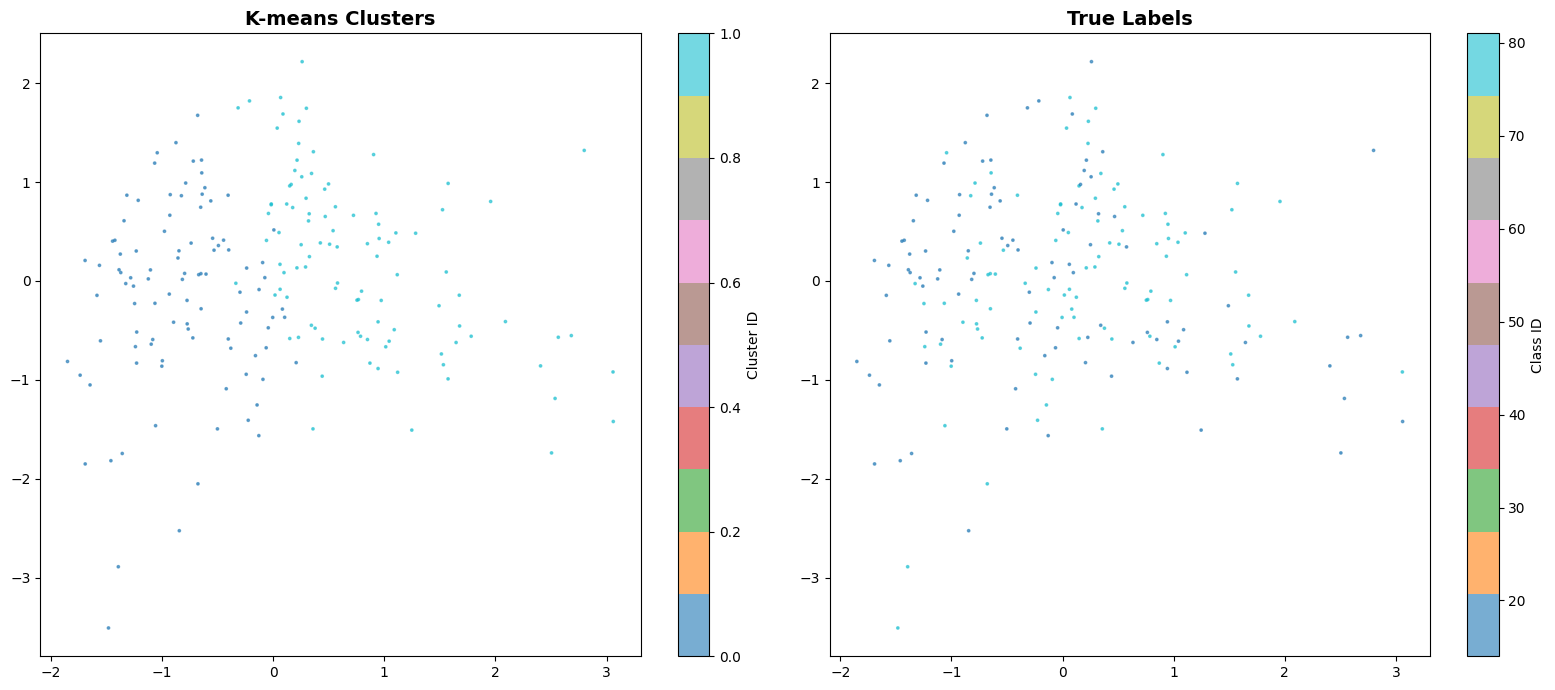

In [18]:
# ładowanie modelu
model_path= '../training_results/masked_autoencoder/cifar100/masked_autoencoder_cifar100_best_20260112_234816.pt'
model, checkpoint = load_trained_model(model_path, model_type='mae')
# print(model)
# print(checkpoint)

selected_classes = checkpoint.get('selected_classes', None)
# print(model)
# print(checkpoint)
# ładowanie danych testowych
batch_size = 64
_, _, _, _, test_loader = create_and_load_subset(2, batch_size=batch_size, selected_classes=selected_classes)

# print(f"Obrazów testowych: {len(test_loader)}")
# for batch_idx, (image, _) in enumerate(test_loader):
#     print(f"Batch {batch_idx} / {len(test_loader)}")


# wyciąganie cech
features, labels = extract_features(model, test_loader)

# klasteryzacja
n_clusters = 2
cluster_ids, kmeans, metrics = clustering(features, labels, n_clusters)

# zapis wynikow
BASE_DIR = os.getcwd()
save_dir = os.path.join(BASE_DIR, '../..', 'experiments', 'masked_autoencoder','cifar100')
os.makedirs(save_dir, exist_ok=True)
results_df, summary_df = save_results_to_csv(cluster_ids, labels, metrics, save_dir)

# wizualizacja
vis_path = os.path.join(save_dir, 'clusters_visualization.png')
visualize_clusters(features, cluster_ids, labels, vis_path)


tsne_path = os.path.join(save_dir, 'clusters_tsne_visualization.png')
visualize_clusters_tsne(features, cluster_ids, labels, tsne_path)
analyze_cluster_composition(cluster_ids, labels, n_clusters)
visualize_cluster_samples(cluster_ids, test_loader, cluster_id=0, n_samples=25)
cluster_purity(cluster_ids, labels)



# Ekstrakcja i klasteryzacja dla CMAE i cifar10

Model załadowany
Epoka: 45
Train Loss: 0.049636
Val Loss: 0.057030
Latent Dim: 256

Features: torch.Size([64, 256])
Wyciągnięto cechy: (10000, 256)
NMI (Normalized Mutual Information): 0.0759
ARI (Adjusted Rand Index): 0.0296
Inertia: 1390.01



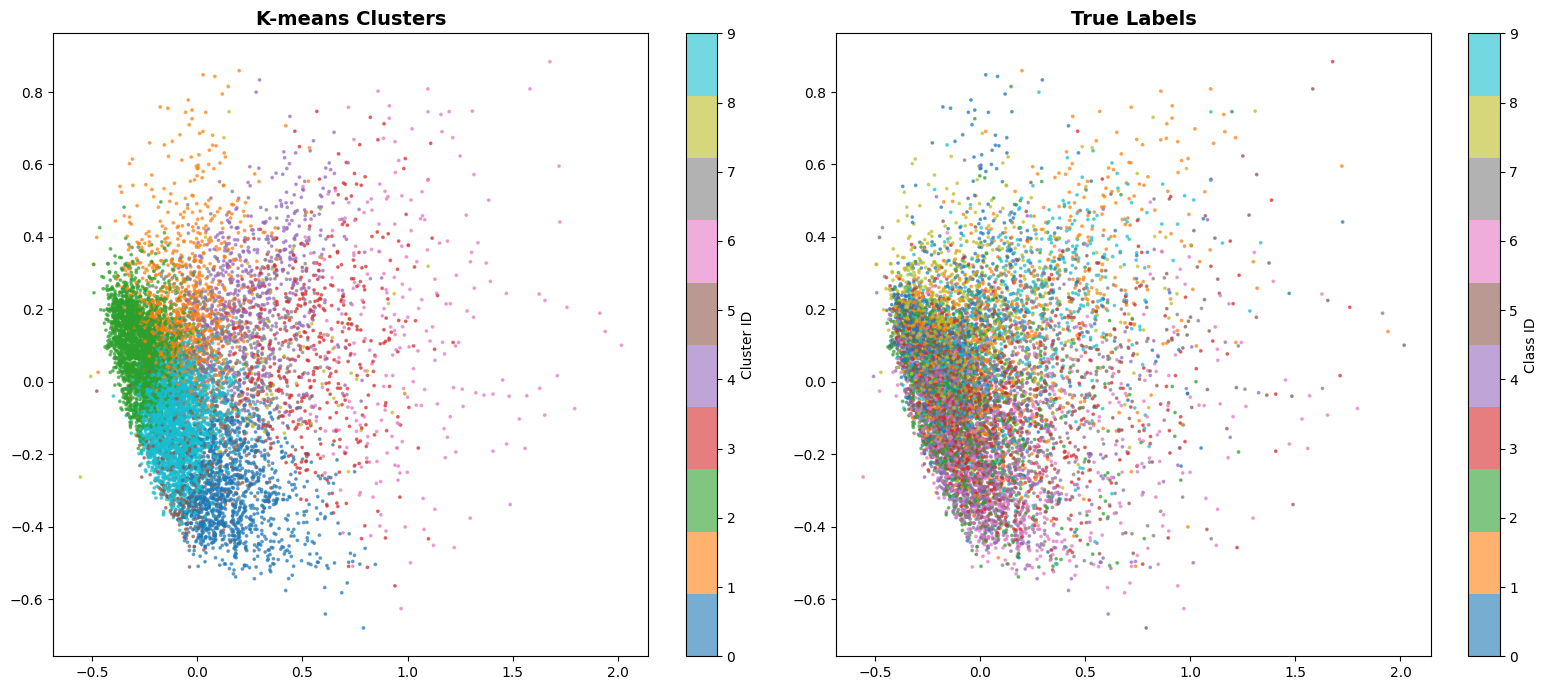

In [37]:
# ładowanie modelu
model_path= '../training_results/cmae/cifar10/cmae_cifar10_best_20260111_193204.pt'
model, checkpoint = load_trained_model(model_path, model_type='cmae')
# print(model)
# print(checkpoint)


# ładowanie danych testowych
batch_size = 64
_, _, test_loader = get_cifar100_loaders(batch_size=batch_size)
# print(f"Obrazów testowych: {len(test_loader)}")
# for batch_idx, (image, _) in enumerate(test_loader):
#     print(f"Batch {batch_idx} / {len(test_loader)}")


# wyciąganie cech
features, labels = extract_features(model, test_loader)

# klasteryzacja
n_clusters = 10
cluster_ids, kmeans, metrics = clustering(features, labels, n_clusters)

# zapis wynikow
BASE_DIR = os.getcwd()
save_dir = os.path.join(BASE_DIR, '../..', 'experiments', 'cmae','cifar10')
os.makedirs(save_dir, exist_ok=True)
results_df, summary_df = save_results_to_csv(cluster_ids, labels, metrics, save_dir)

# wizualizacja
vis_path = os.path.join(save_dir, 'clusters_visualization.png')
visualize_clusters(features, cluster_ids, labels, vis_path)

tsne_path = os.path.join(save_dir, 'clusters_tsne_visualization.png')
visualize_clusters_tsne(features, cluster_ids, labels, tsne_path)
analyze_cluster_composition(cluster_ids, labels, n_clusters)
visualize_cluster_samples(cluster_ids, test_loader, cluster_id=0, n_samples=25)
cluster_purity(cluster_ids, labels)



#  Ekstrakcja i klasteryzacja dla CMAE i cifar100

Model załadowany
Epoka: 237
Train Loss: 1.129760
Val Loss: 1.297885
Latent Dim: 256

Używam podanych klas: [87, 70]
Features: torch.Size([64, 256])
Wyciągnięto cechy: (200, 256)
[70 87]
=== K-means ===
NMI (Normalized Mutual Information): 0.0238
ARI (Adjusted Rand Index): 0.0276
Silhouette: 0.1387
Inertia: 57.39



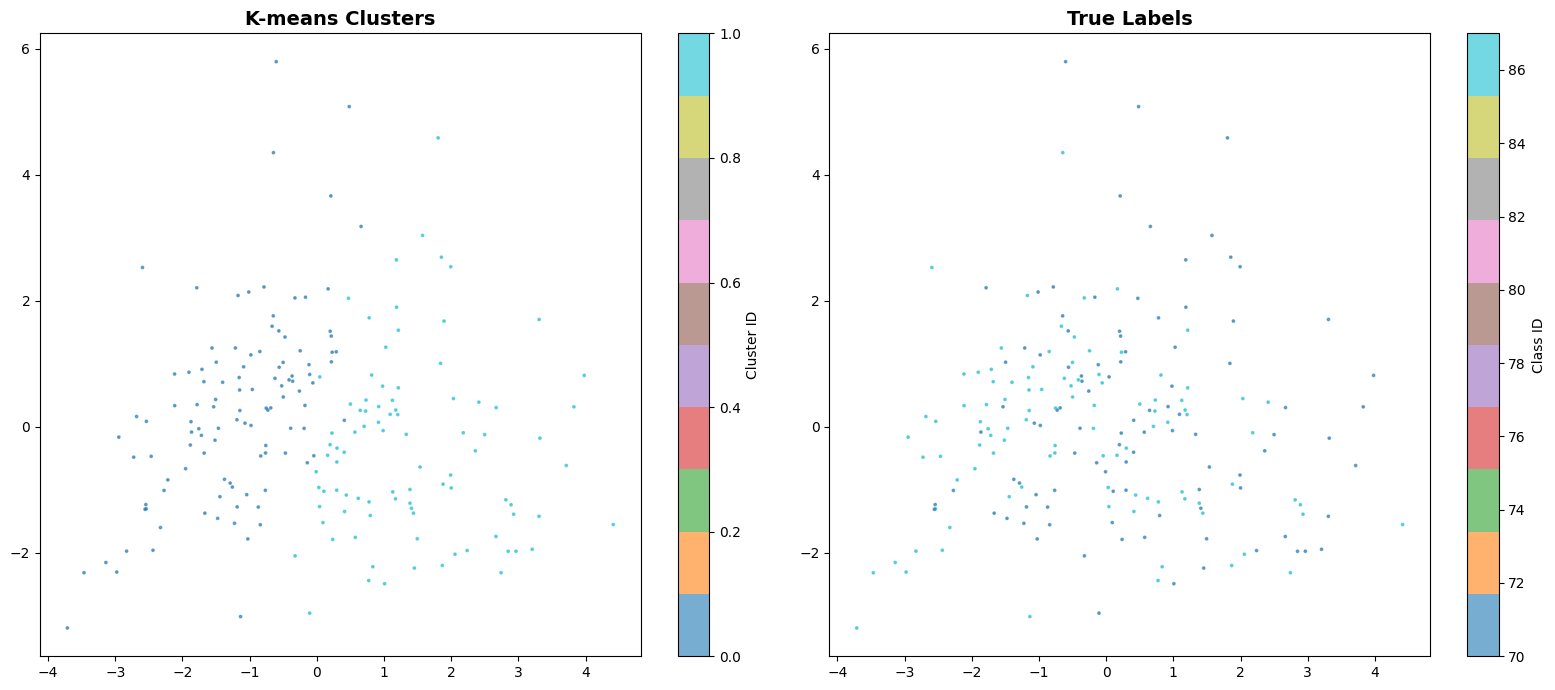

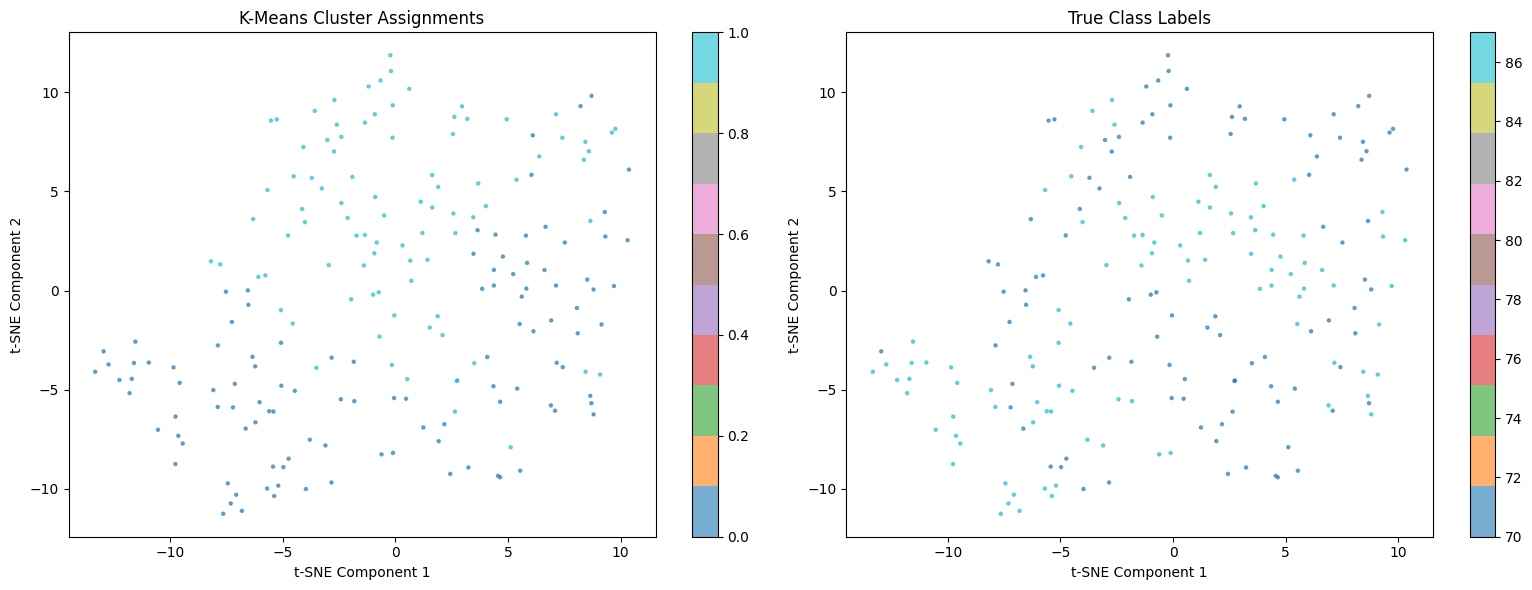

Klaster 0 (rozmiar: 110):
  Klasa 87:  64 obrazów ( 58.2%)
  Klasa 70:  46 obrazów ( 41.8%)

Klaster 1 (rozmiar: 90):
  Klasa 70:  54 obrazów ( 60.0%)
  Klasa 87:  36 obrazów ( 40.0%)



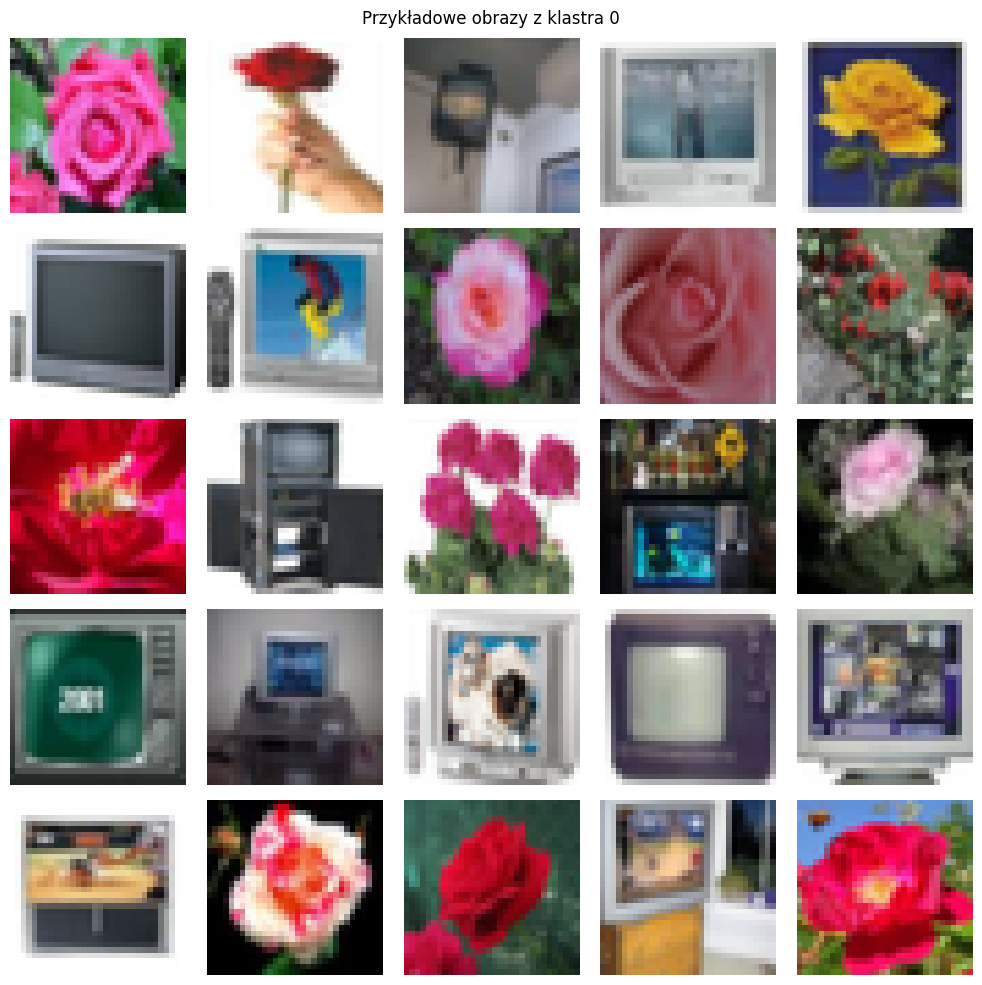

Średnia czystość klastrów: 0.5909


np.float64(0.5909090909090908)

In [15]:
# ładowanie modelu
model_path= '../training_results/cmae/cifar100/2_classes_sprawdzenie/cmae_cifar100_best_trening_1_20260119_142216.pt'
model, checkpoint = load_trained_model(model_path, model_type='cmae')
selected_classes = checkpoint.get('selected_classes', None)
# print(model)
# print(checkpoint)


# ładowanie danych testowych
batch_size = 64
_, _, _, _, test_loader = create_and_load_subset(2, batch_size=batch_size, seed=42, selected_classes=selected_classes)

# print(f"Obrazów testowych: {len(test_loader)}")
# for batch_idx, (image, _) in enumerate(test_loader):
#     print(f"Batch {batch_idx} / {len(test_loader)}")


# wyciąganie cech
features, labels = extract_features(model, test_loader)
print(np.unique(labels))
# klasteryzacja
n_clusters = 2
cluster_ids, kmeans, metrics = clustering(features, labels, n_clusters)

# zapis wynikow
BASE_DIR = os.getcwd()
save_dir = os.path.join(BASE_DIR, '../..', 'experiments', 'cmae','cifar100')
os.makedirs(save_dir, exist_ok=True)
results_df, summary_df = save_results_to_csv(cluster_ids, labels, metrics, save_dir)

# wizualizacja
vis_path = os.path.join(save_dir, 'clusters_visualization_proba.png')
visualize_clusters(features, cluster_ids, labels, vis_path)
tsne_path = os.path.join(save_dir, 'clusters_tsne_visualization_proba.png')
visualize_clusters_tsne(features, cluster_ids, labels, tsne_path)
analyze_cluster_composition(cluster_ids, labels, n_clusters)
visualize_cluster_samples(cluster_ids, test_loader, cluster_id=0, n_samples=25)
cluster_purity(cluster_ids, labels)



Przetwarzanie modelu 1/5 dla 2 klas

Model załadowany
Epoka: 242
Train Loss: 0.608169
Val Loss: 0.608920
Latent Dim: 256

Używam podanych klas: [60, 78]
Wyciąganie cech dla modelu 1...
Features: torch.Size([64, 256])
Wyciągnięto cechy: (200, 256)
Unikalne etykiety: [60 78]

Klasteryzacja dla modelu 1...
=== K-means ===
NMI (Normalized Mutual Information): 0.5960
ARI (Adjusted Rand Index): 0.6873
DBI 2.3612
Silhouette: 0.1429
Inertia: 96.85


Zapisywanie szczegółowych wyników klasteryzacji dla modelu 1...
Zapisano przypisania klastrów do: clustering_assignments_2_classes_model_1.csv
Zapisano metryki do: clustering_metrics_2_classes_model_1.csv
Generowanie wizualizacji PCA dla modelu 1...


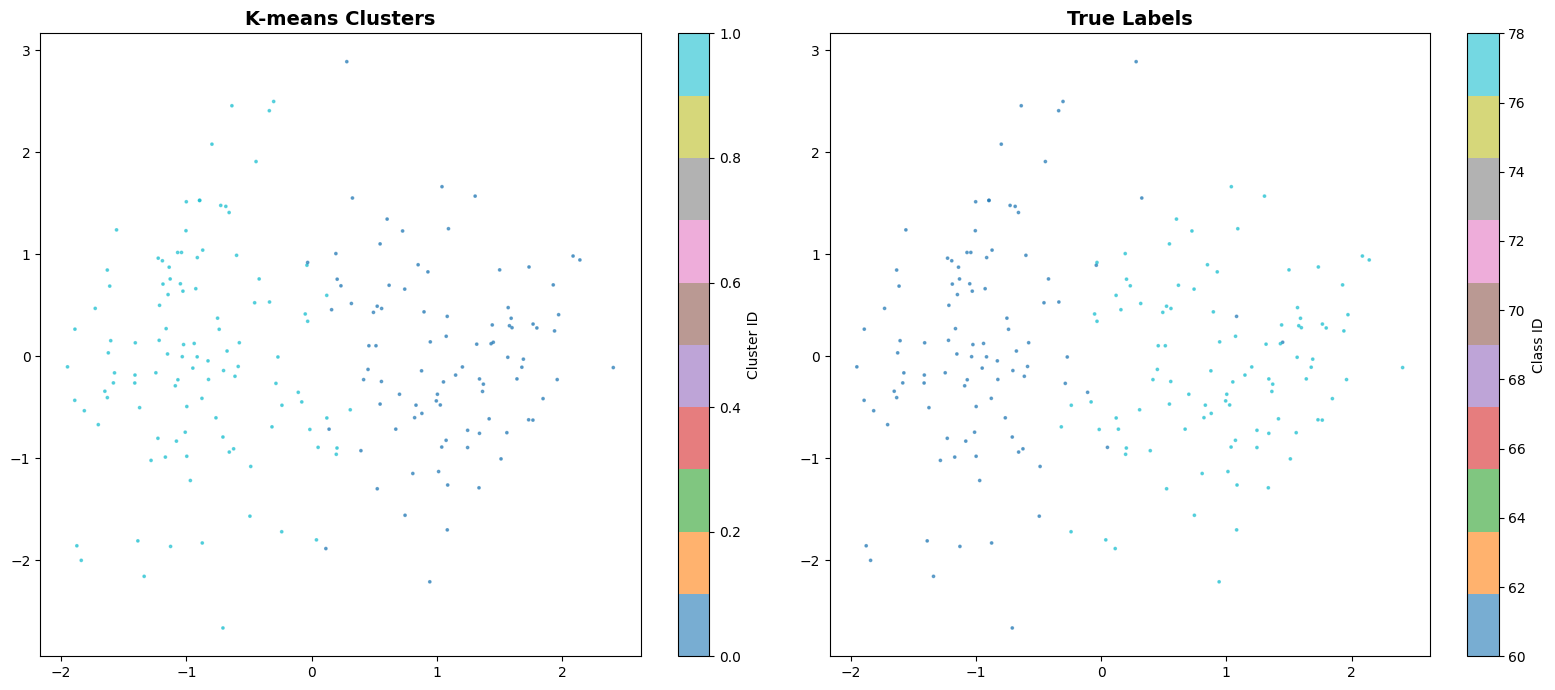

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


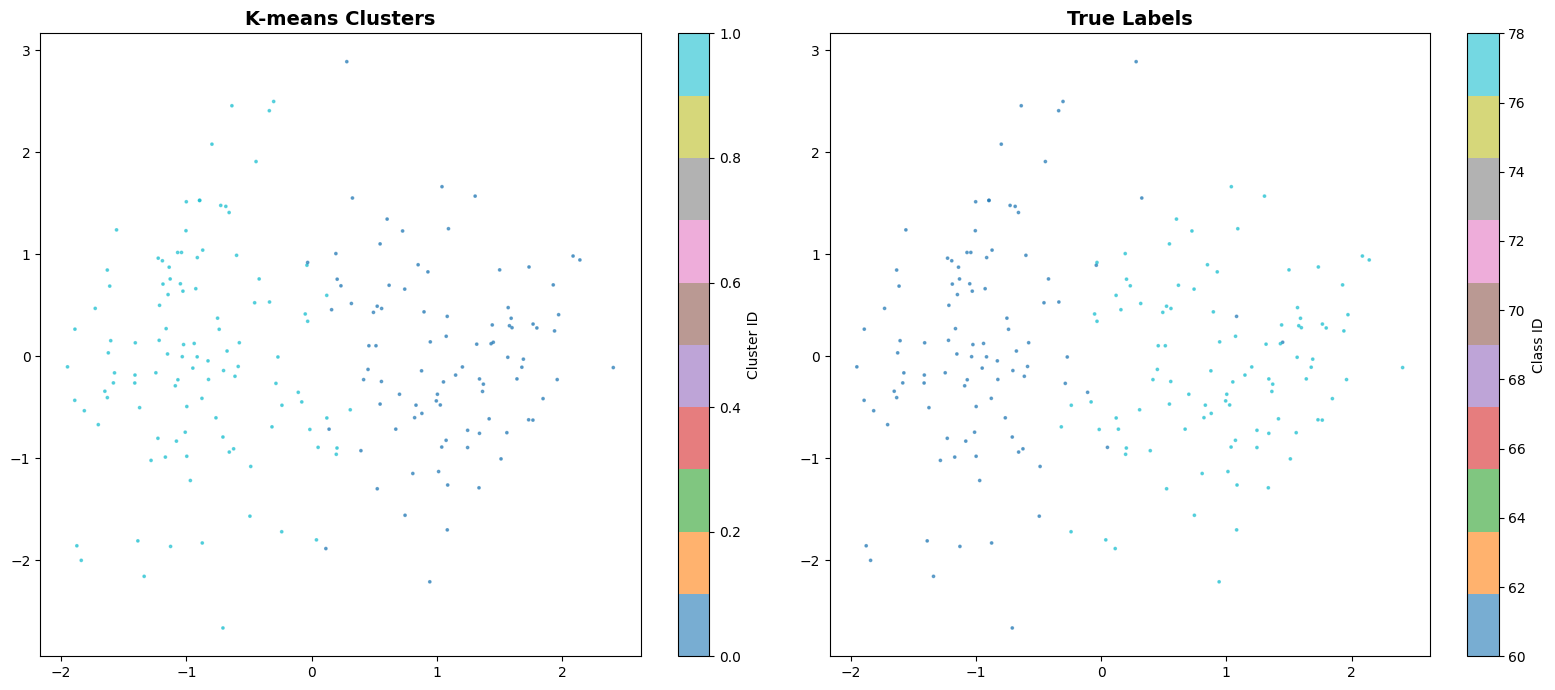

Generowanie wizualizacji t-SNE dla modelu 1...


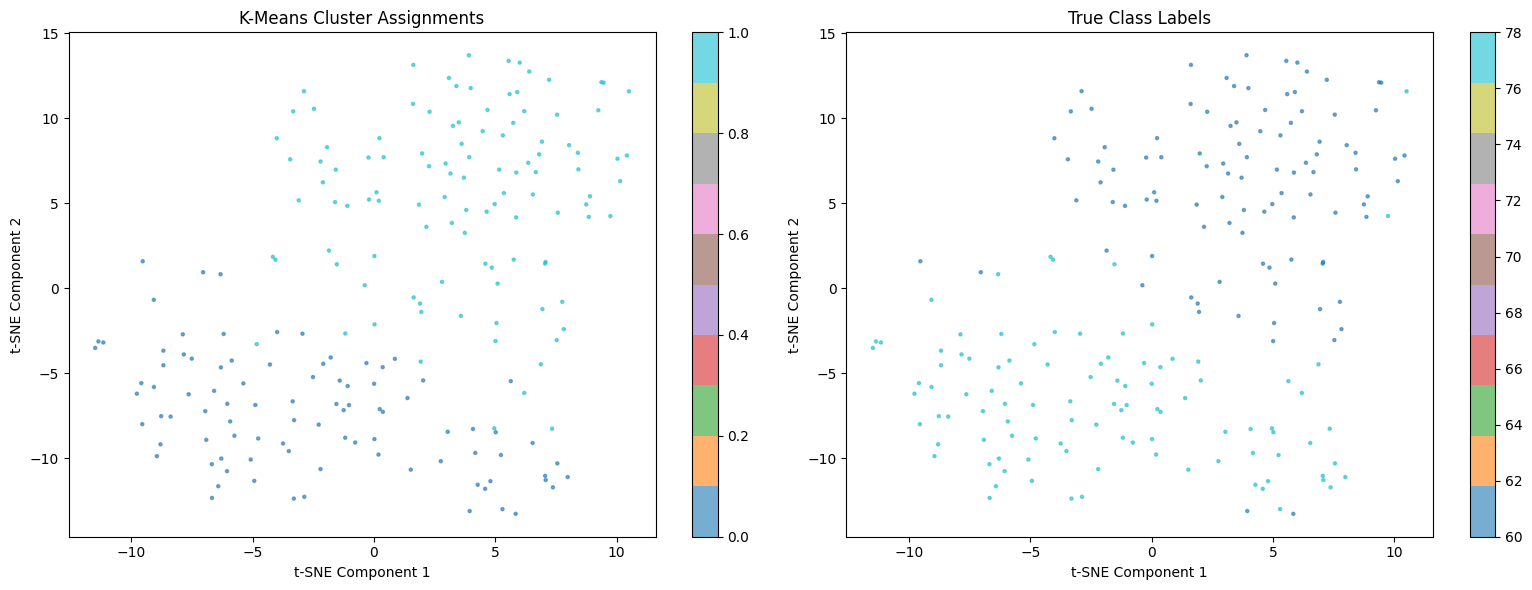

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


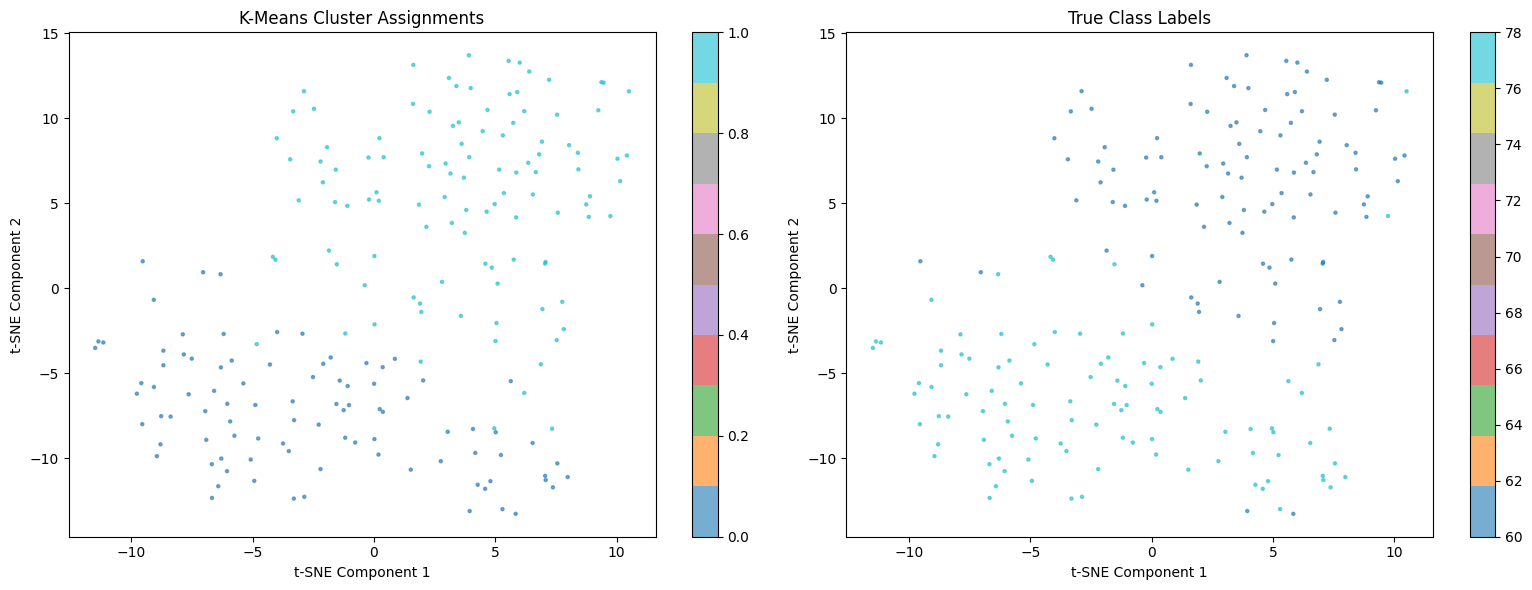


Analiza składu klastrów dla modelu 1...
Klaster 0 (rozmiar: 91):
  Klasa 78:  87 obrazów ( 95.6%)
  Klasa 60:   4 obrazów (  4.4%)

Klaster 1 (rozmiar: 109):
  Klasa 60:  96 obrazów ( 88.1%)
  Klasa 78:  13 obrazów ( 11.9%)


Wizualizacja próbek klastrów dla modelu 1...


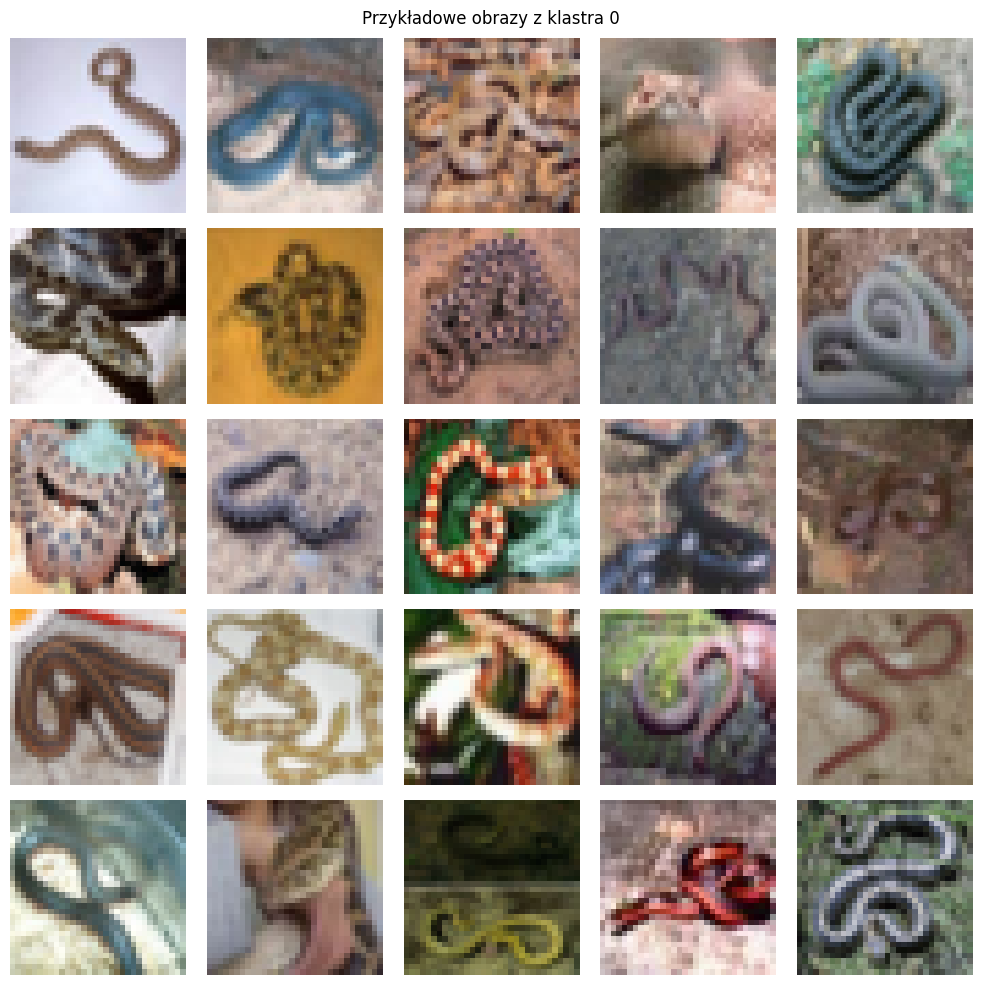


Czystość klastrów dla modelu 1...
Średnia czystość klastrów: 0.9184

Zakończono przetwarzanie modelu 1


Przetwarzanie modelu 2/5 dla 2 klas

Model załadowany
Epoka: 213
Train Loss: 0.761686
Val Loss: 0.838026
Latent Dim: 256

Używam podanych klas: [89, 81]
Wyciąganie cech dla modelu 2...
Features: torch.Size([64, 256])
Wyciągnięto cechy: (200, 256)
Unikalne etykiety: [81 89]

Klasteryzacja dla modelu 2...
=== K-means ===
NMI (Normalized Mutual Information): 0.0078
ARI (Adjusted Rand Index): 0.0053
DBI 2.8020
Silhouette: 0.1042
Inertia: 92.67


Zapisywanie szczegółowych wyników klasteryzacji dla modelu 2...
Zapisano przypisania klastrów do: clustering_assignments_2_classes_model_2.csv
Zapisano metryki do: clustering_metrics_2_classes_model_2.csv
Generowanie wizualizacji PCA dla modelu 2...


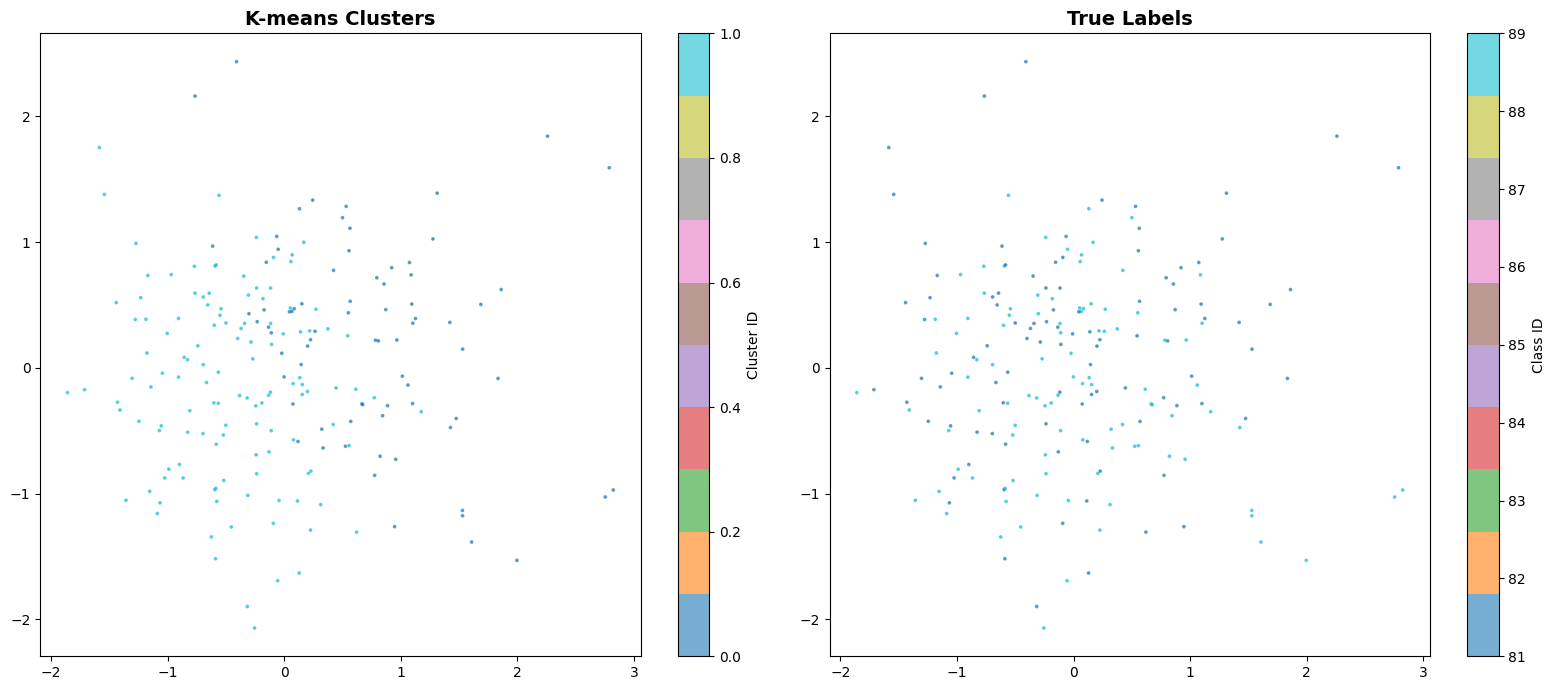

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


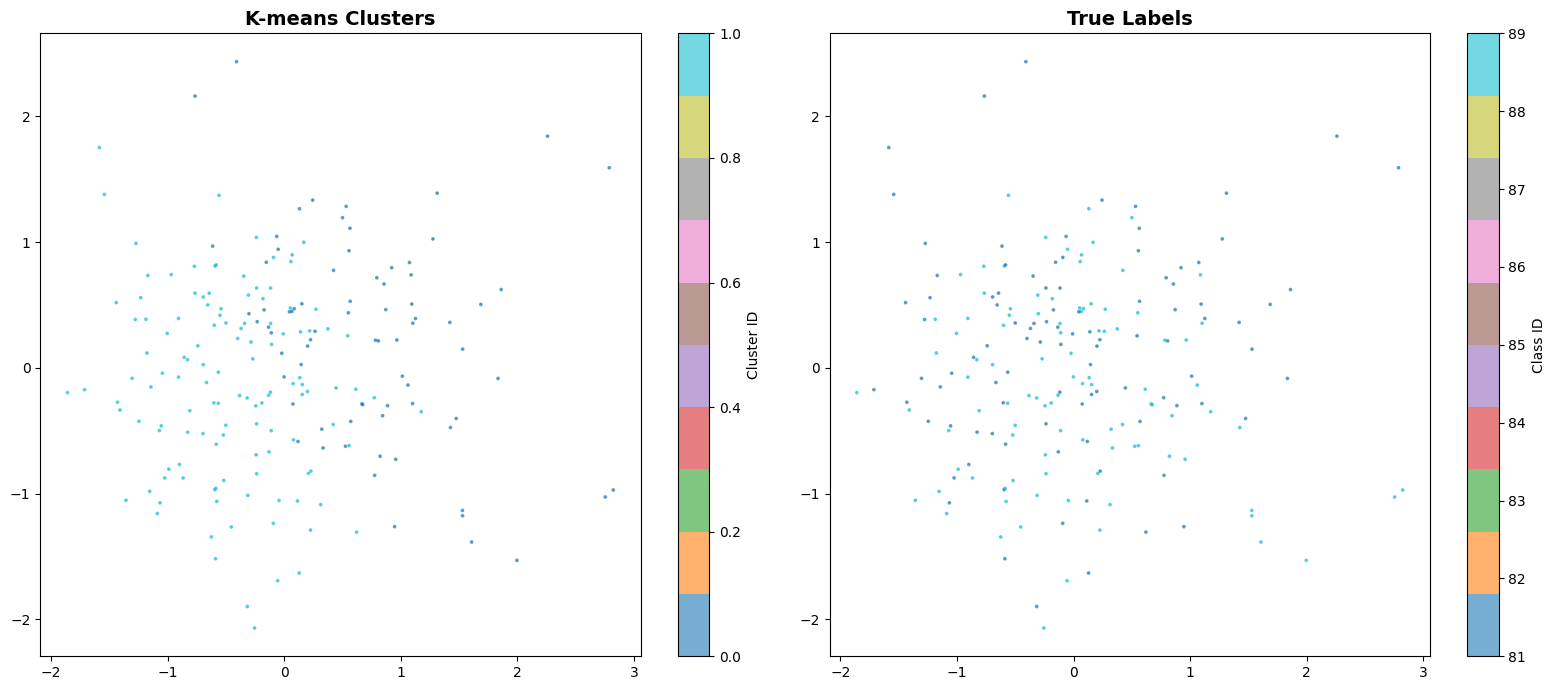

Generowanie wizualizacji t-SNE dla modelu 2...


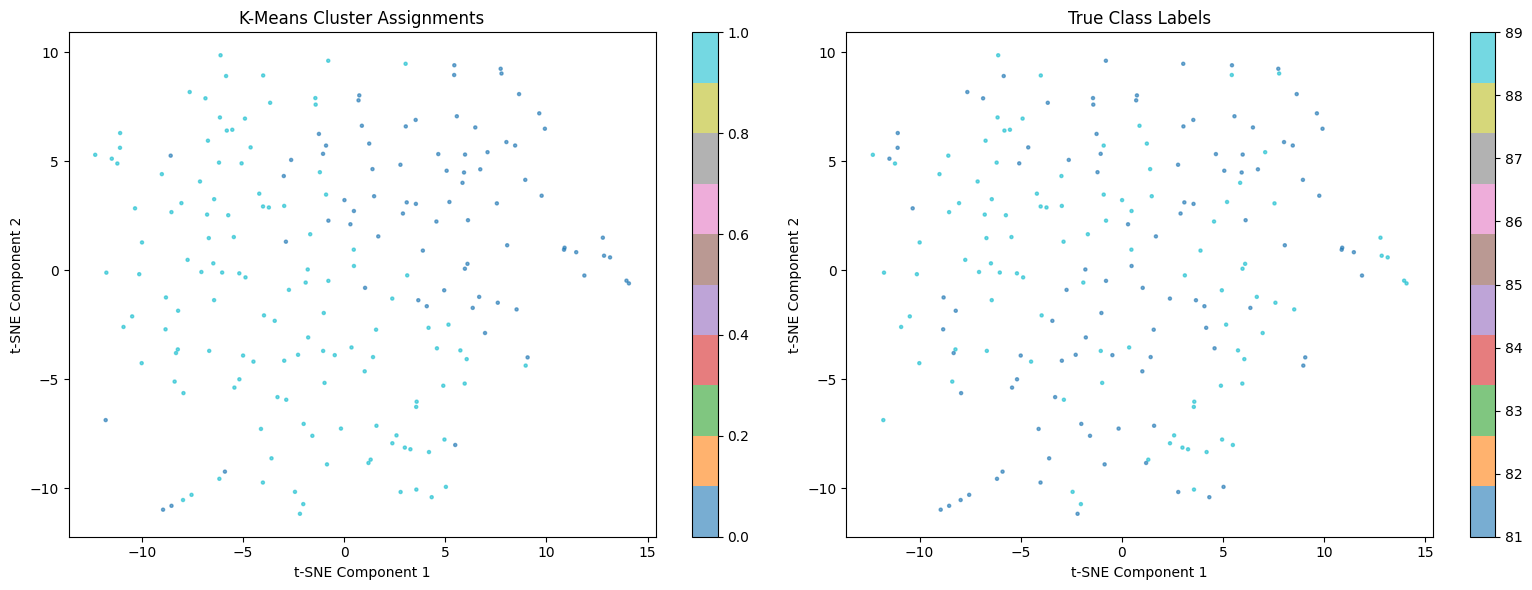

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


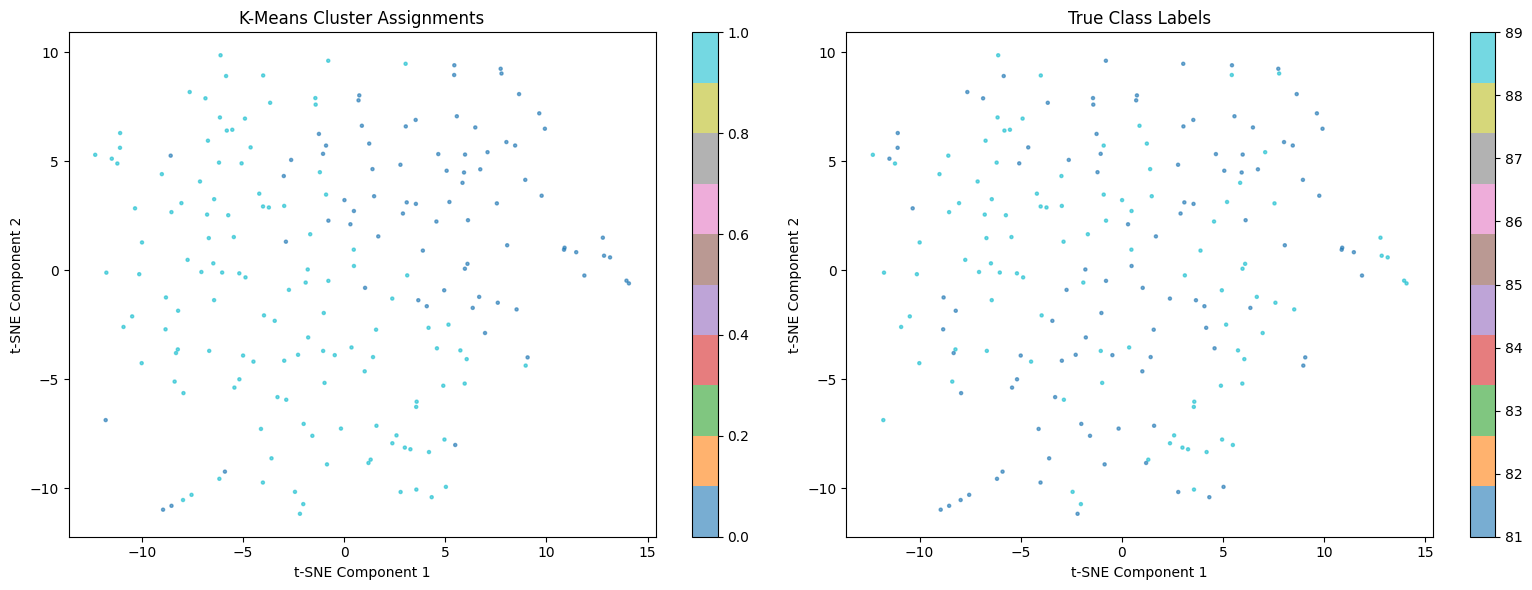


Analiza składu klastrów dla modelu 2...
Klaster 0 (rozmiar: 76):
  Klasa 81:  43 obrazów ( 56.6%)
  Klasa 89:  33 obrazów ( 43.4%)

Klaster 1 (rozmiar: 124):
  Klasa 89:  67 obrazów ( 54.0%)
  Klasa 81:  57 obrazów ( 46.0%)


Wizualizacja próbek klastrów dla modelu 2...


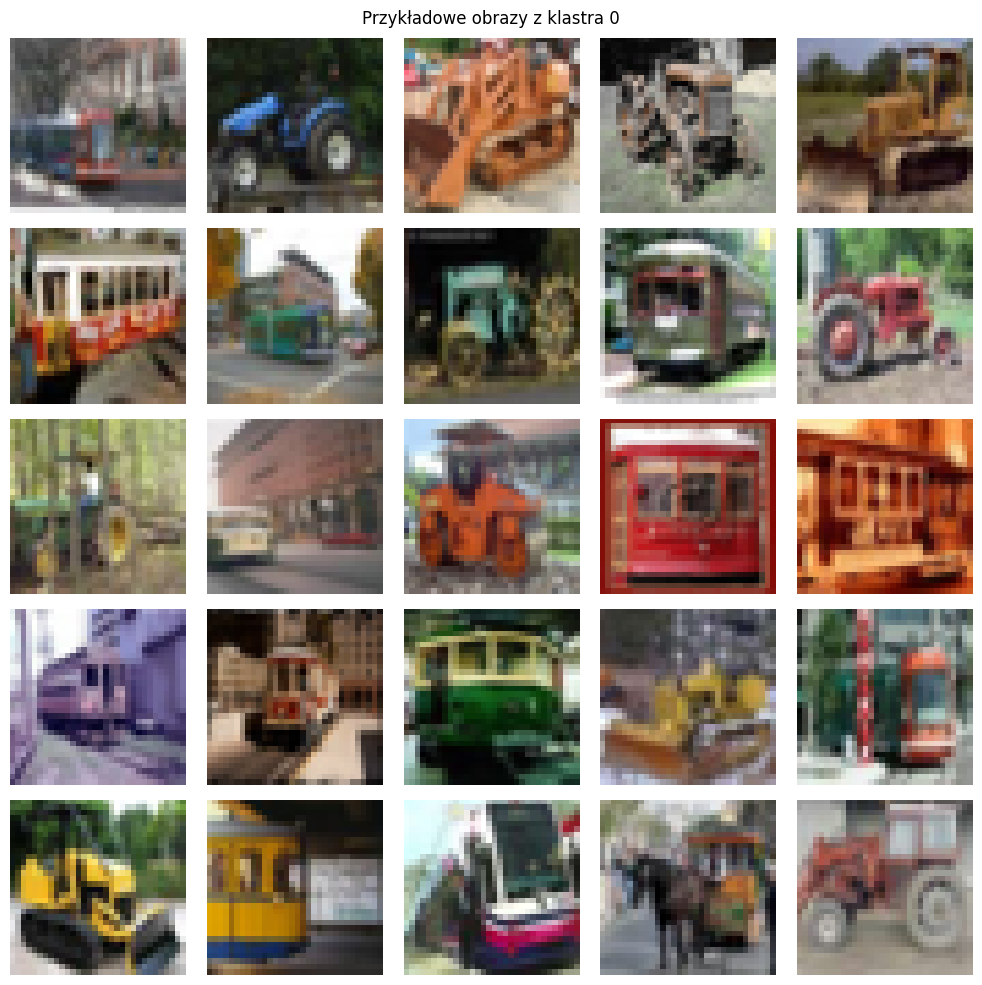


Czystość klastrów dla modelu 2...
Średnia czystość klastrów: 0.5531

Zakończono przetwarzanie modelu 2


Przetwarzanie modelu 3/5 dla 2 klas

Model załadowany
Epoka: 134
Train Loss: 0.626518
Val Loss: 0.634079
Latent Dim: 256

Używam podanych klas: [25, 69]
Wyciąganie cech dla modelu 3...
Features: torch.Size([64, 256])
Wyciągnięto cechy: (200, 256)
Unikalne etykiety: [25 69]

Klasteryzacja dla modelu 3...
=== K-means ===
NMI (Normalized Mutual Information): 0.2615
ARI (Adjusted Rand Index): 0.3331
DBI 2.2434
Silhouette: 0.1434
Inertia: 84.88


Zapisywanie szczegółowych wyników klasteryzacji dla modelu 3...
Zapisano przypisania klastrów do: clustering_assignments_2_classes_model_3.csv
Zapisano metryki do: clustering_metrics_2_classes_model_3.csv
Generowanie wizualizacji PCA dla modelu 3...


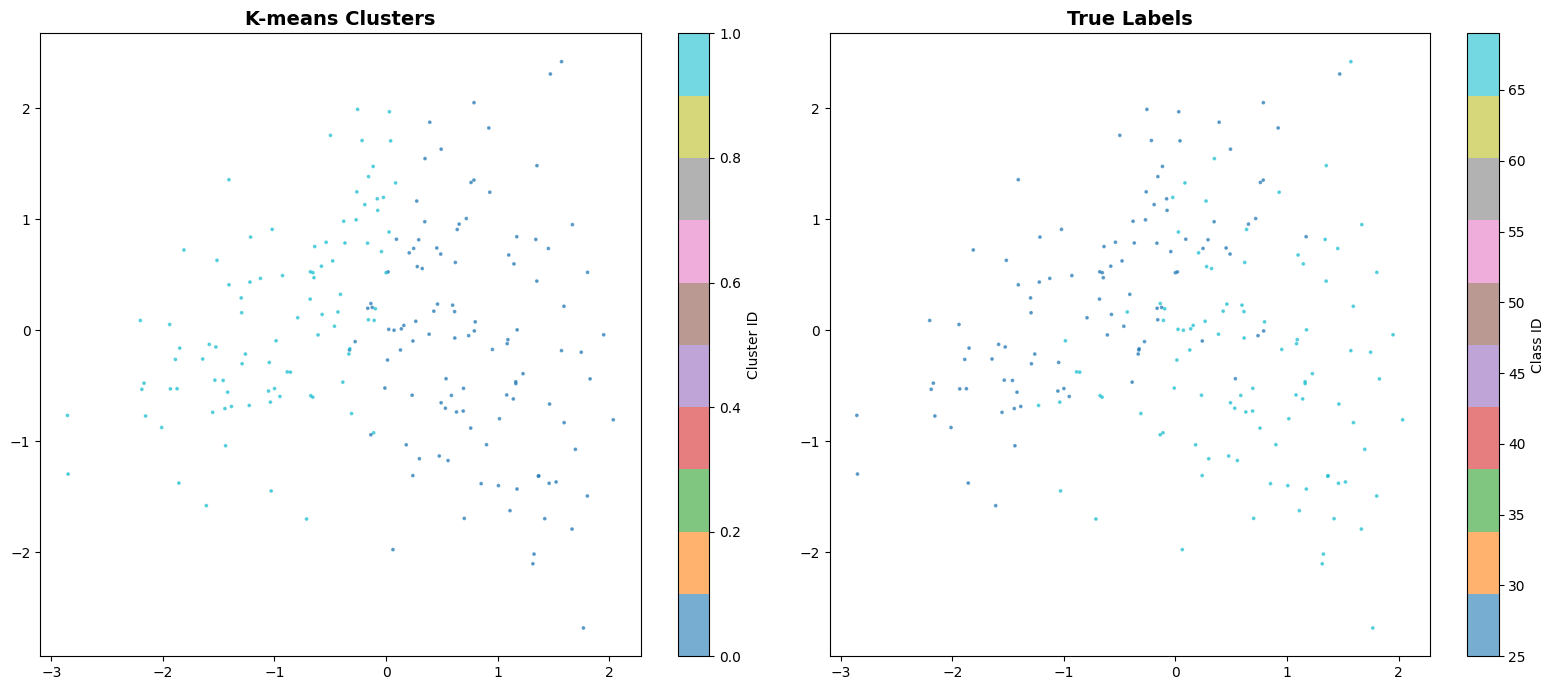

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


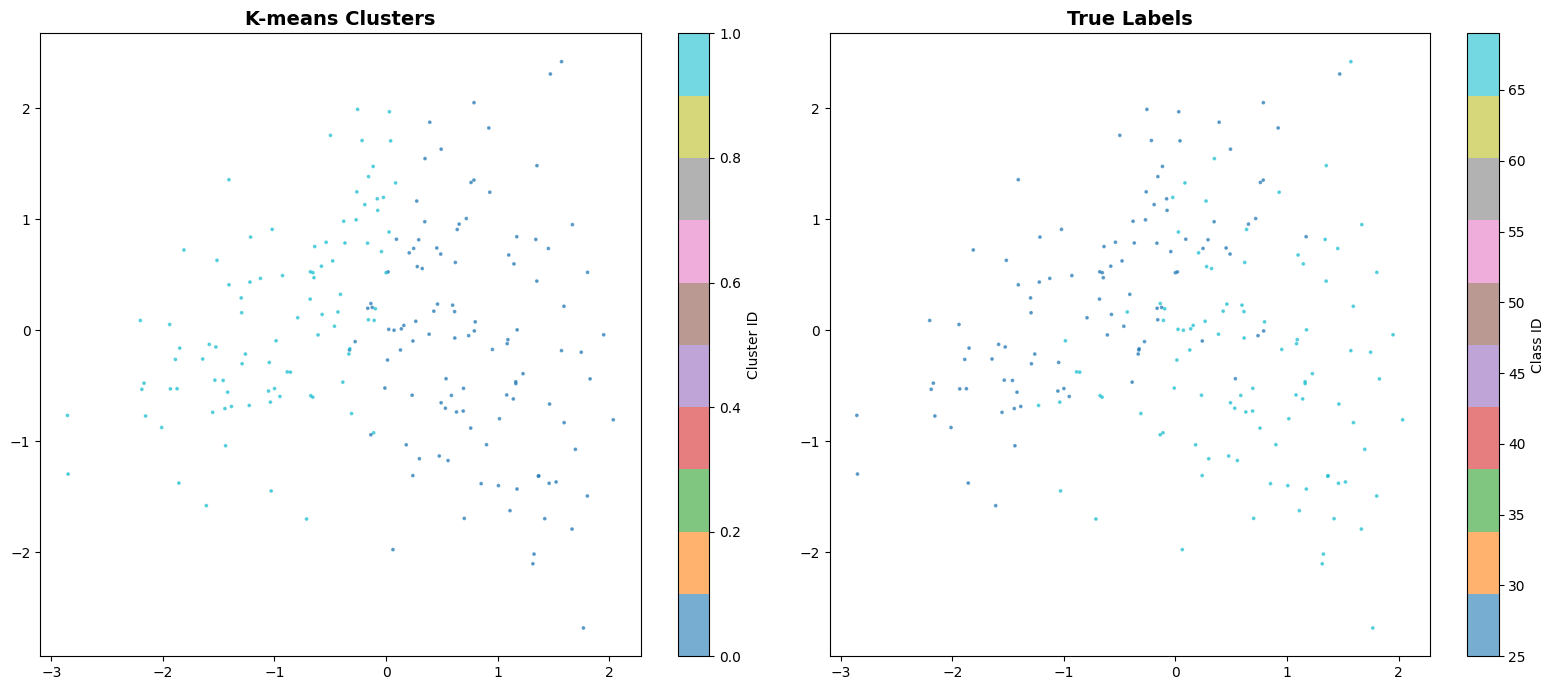

Generowanie wizualizacji t-SNE dla modelu 3...


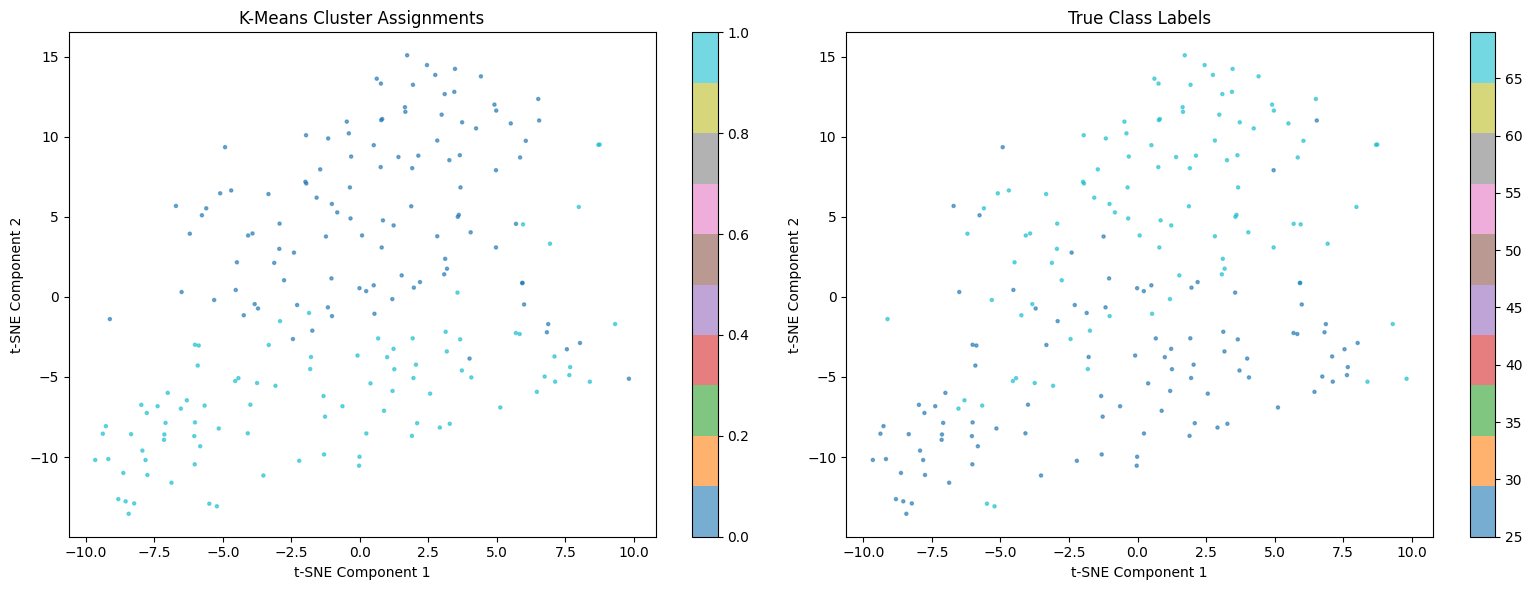

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


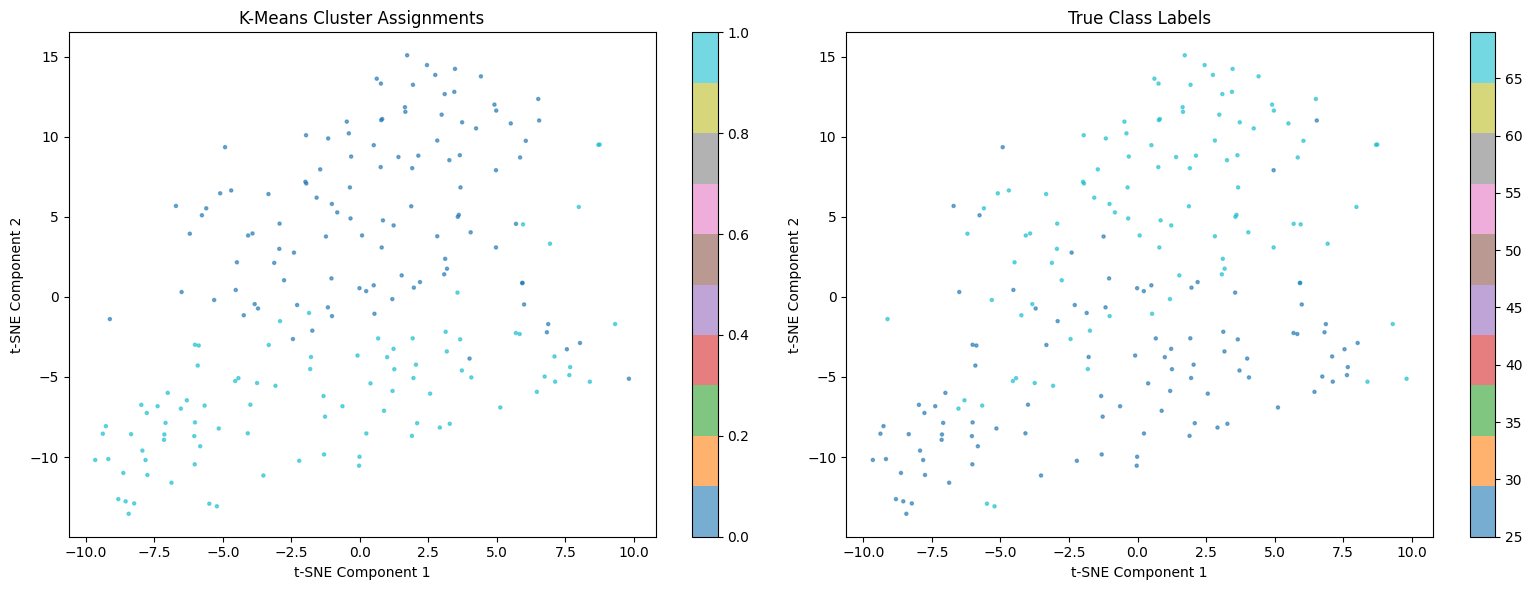


Analiza składu klastrów dla modelu 3...
Klaster 0 (rozmiar: 108):
  Klasa 69:  83 obrazów ( 76.9%)
  Klasa 25:  25 obrazów ( 23.1%)

Klaster 1 (rozmiar: 92):
  Klasa 25:  75 obrazów ( 81.5%)
  Klasa 69:  17 obrazów ( 18.5%)


Wizualizacja próbek klastrów dla modelu 3...


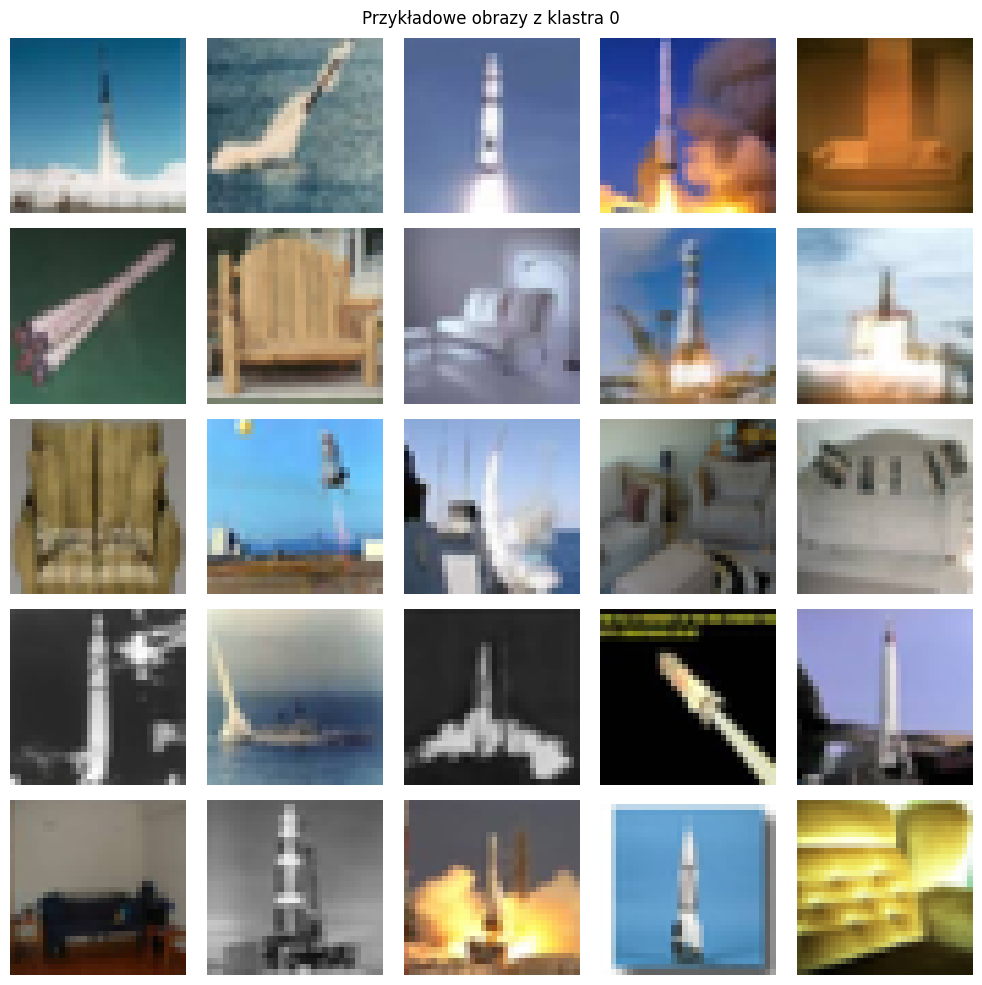


Czystość klastrów dla modelu 3...
Średnia czystość klastrów: 0.7919

Zakończono przetwarzanie modelu 3


Przetwarzanie modelu 4/5 dla 2 klas

Model załadowany
Epoka: 184
Train Loss: 0.682473
Val Loss: 0.753619
Latent Dim: 256

Używam podanych klas: [12, 10]
Wyciąganie cech dla modelu 4...
Features: torch.Size([64, 256])
Wyciągnięto cechy: (200, 256)
Unikalne etykiety: [10 12]

Klasteryzacja dla modelu 4...
=== K-means ===
NMI (Normalized Mutual Information): 0.1251
ARI (Adjusted Rand Index): 0.1639
DBI 2.5175
Silhouette: 0.1238
Inertia: 82.28


Zapisywanie szczegółowych wyników klasteryzacji dla modelu 4...
Zapisano przypisania klastrów do: clustering_assignments_2_classes_model_4.csv
Zapisano metryki do: clustering_metrics_2_classes_model_4.csv
Generowanie wizualizacji PCA dla modelu 4...


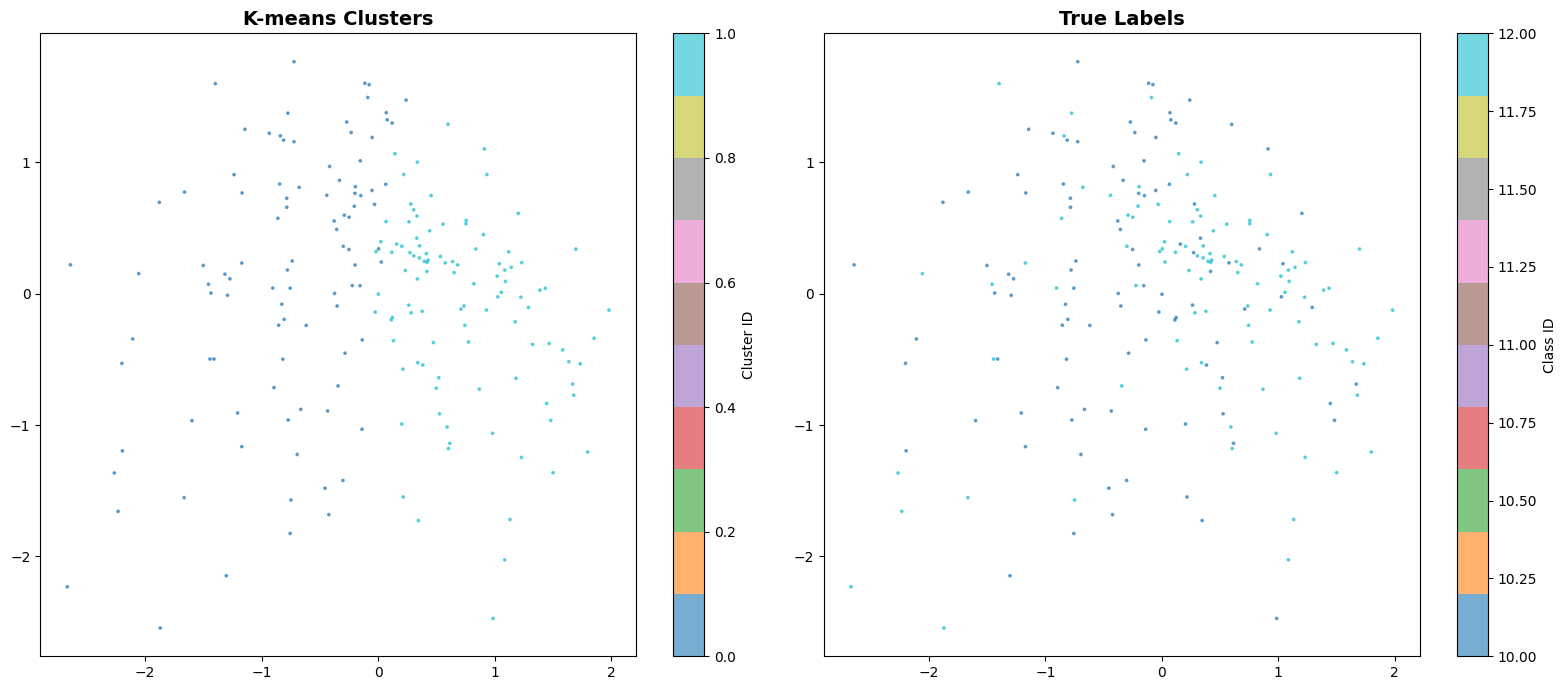

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


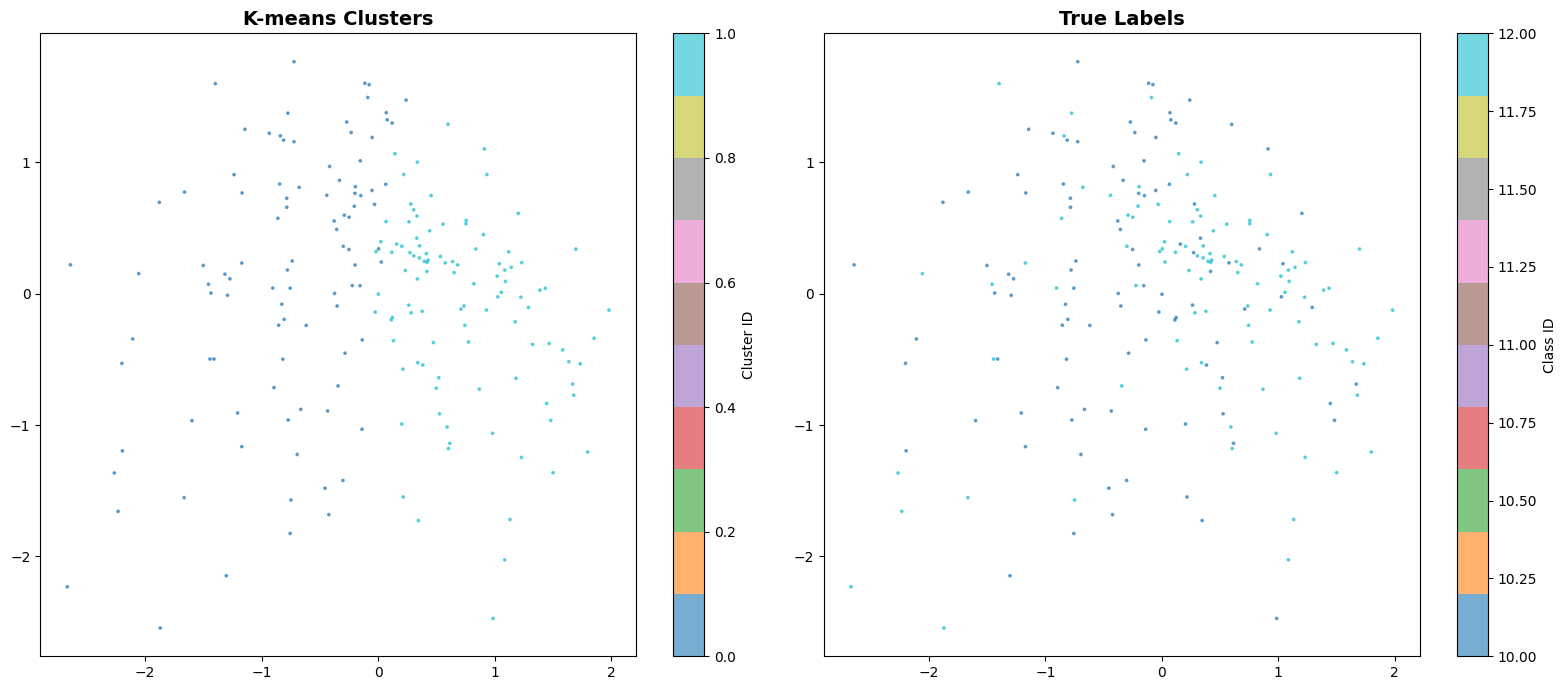

Generowanie wizualizacji t-SNE dla modelu 4...


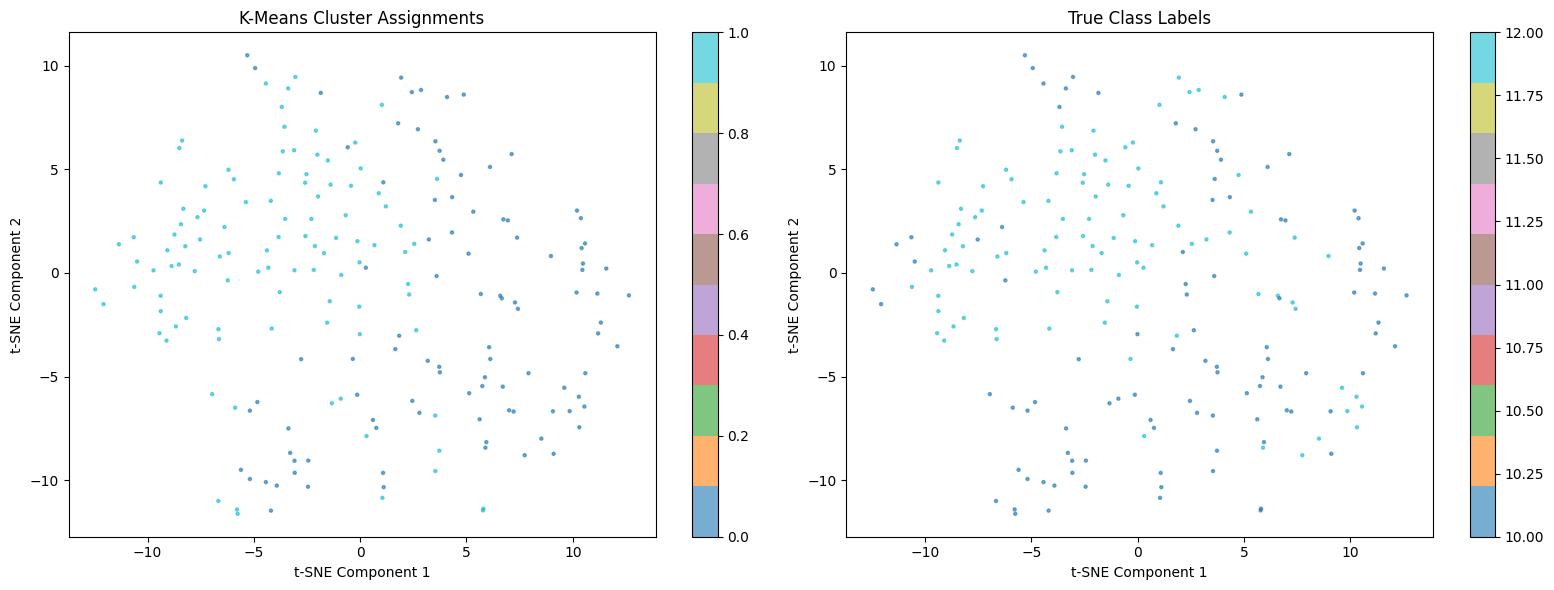

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


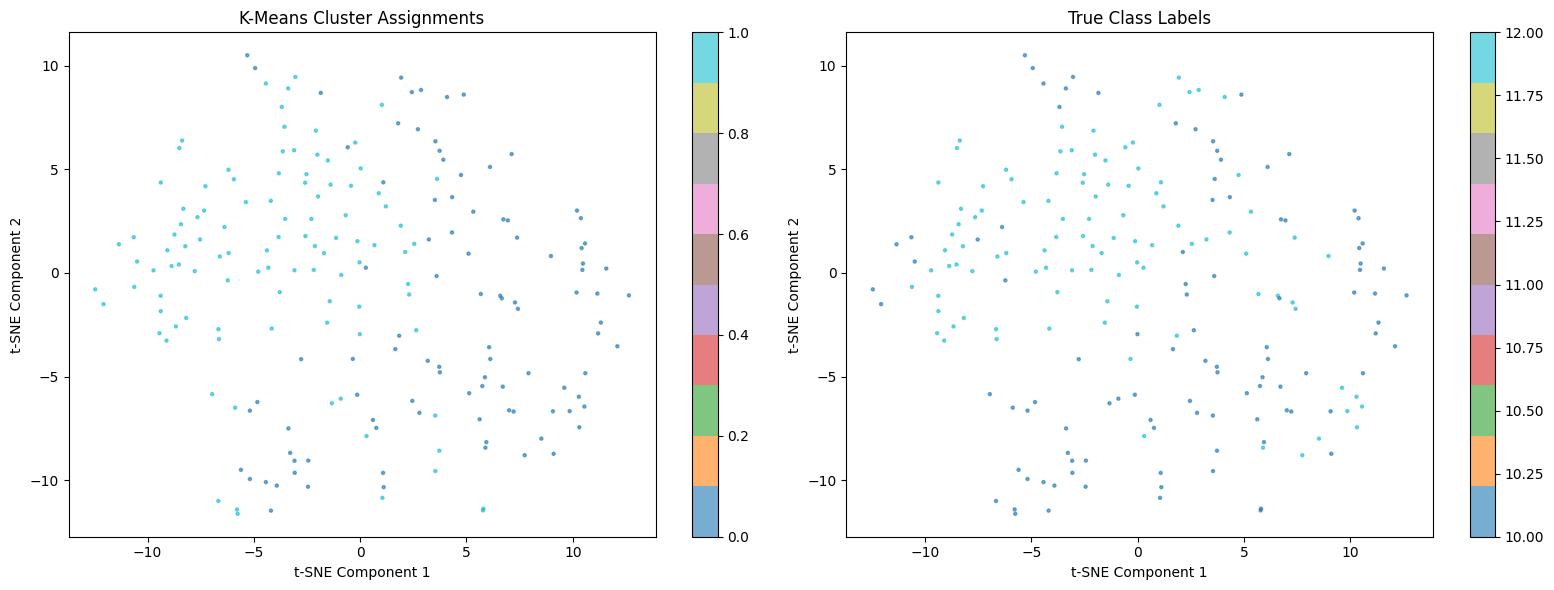


Analiza składu klastrów dla modelu 4...
Klaster 0 (rozmiar: 97):
  Klasa 10:  69 obrazów ( 71.1%)
  Klasa 12:  28 obrazów ( 28.9%)

Klaster 1 (rozmiar: 103):
  Klasa 12:  72 obrazów ( 69.9%)
  Klasa 10:  31 obrazów ( 30.1%)


Wizualizacja próbek klastrów dla modelu 4...


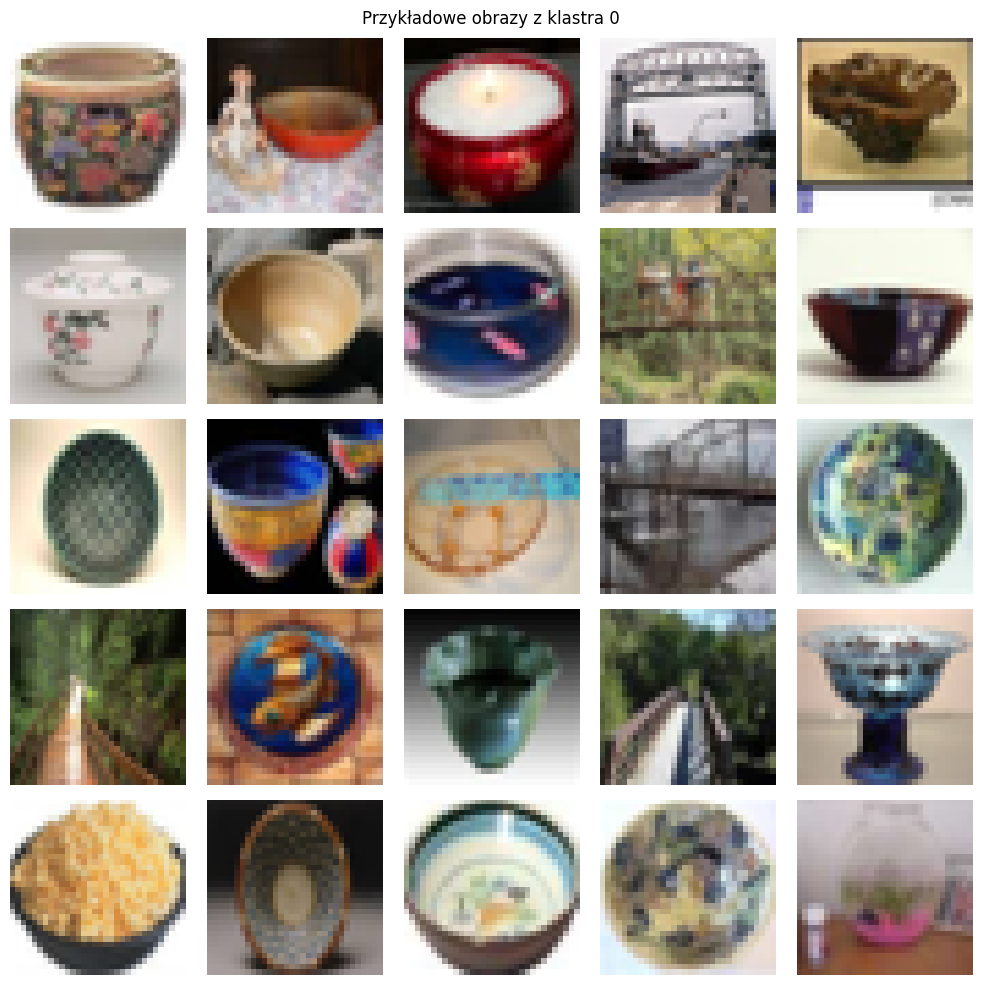


Czystość klastrów dla modelu 4...
Średnia czystość klastrów: 0.7052

Zakończono przetwarzanie modelu 4


Przetwarzanie modelu 5/5 dla 2 klas

Model załadowany
Epoka: 124
Train Loss: 0.744234
Val Loss: 0.779125
Latent Dim: 256

Używam podanych klas: [54, 86]
Wyciąganie cech dla modelu 5...
Features: torch.Size([64, 256])
Wyciągnięto cechy: (200, 256)
Unikalne etykiety: [54 86]

Klasteryzacja dla modelu 5...
=== K-means ===
NMI (Normalized Mutual Information): 0.2653
ARI (Adjusted Rand Index): 0.3331
DBI 1.8925
Silhouette: 0.1941
Inertia: 83.43


Zapisywanie szczegółowych wyników klasteryzacji dla modelu 5...
Zapisano przypisania klastrów do: clustering_assignments_2_classes_model_5.csv
Zapisano metryki do: clustering_metrics_2_classes_model_5.csv
Generowanie wizualizacji PCA dla modelu 5...


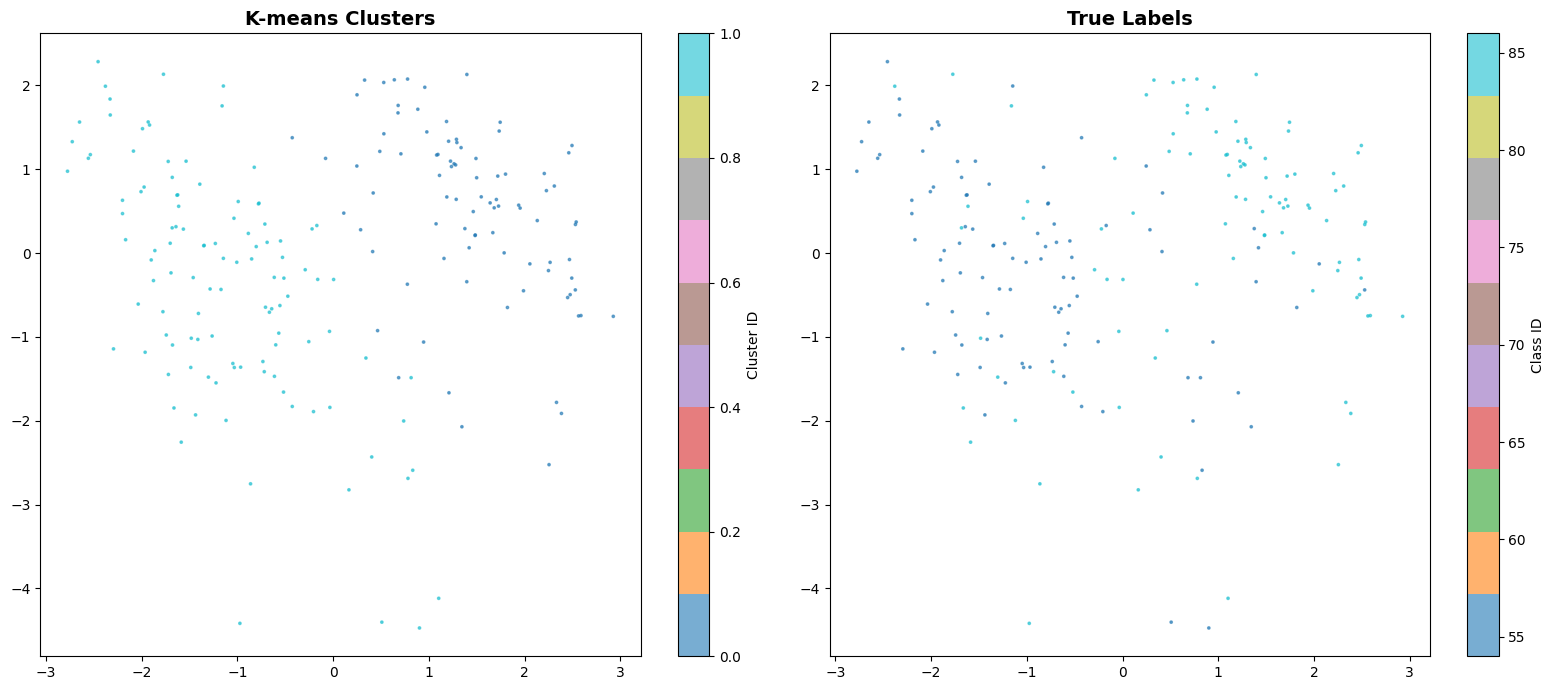

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


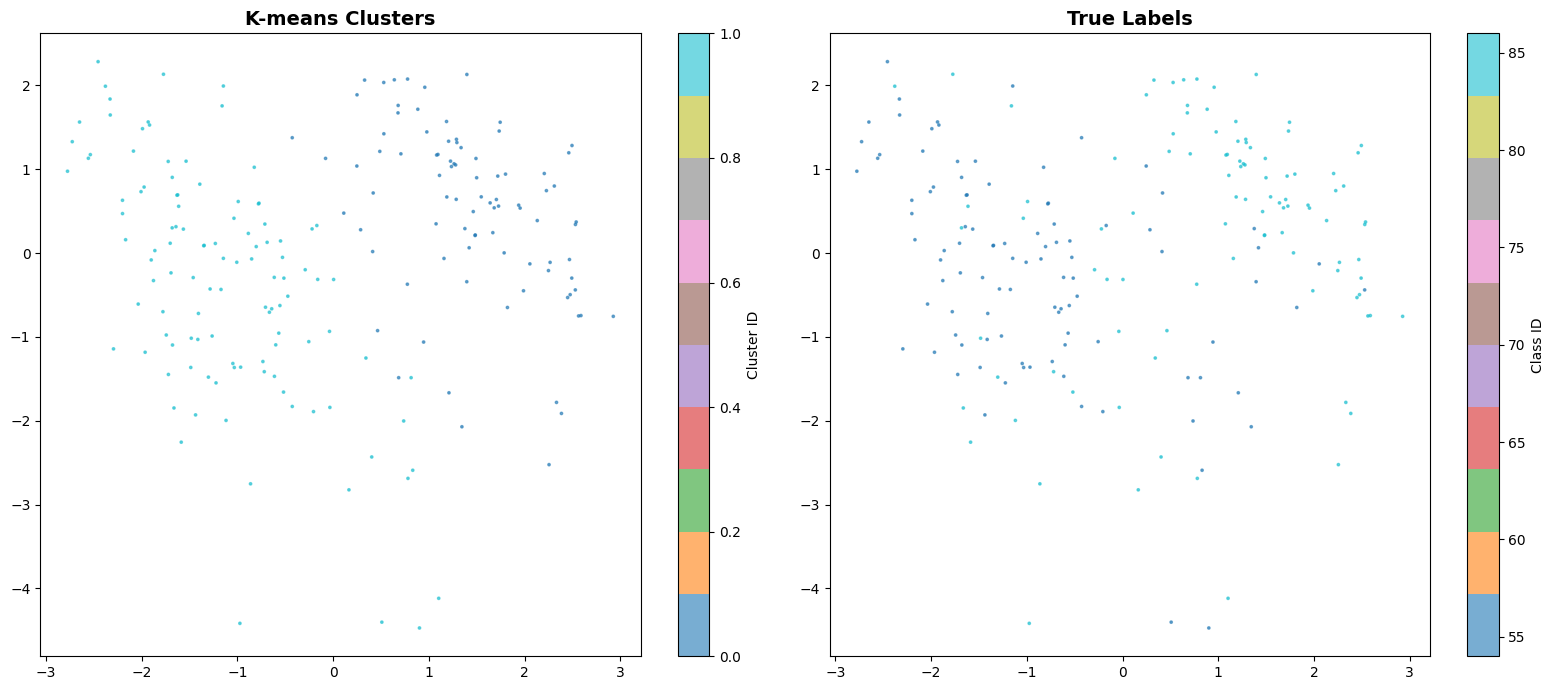

Generowanie wizualizacji t-SNE dla modelu 5...


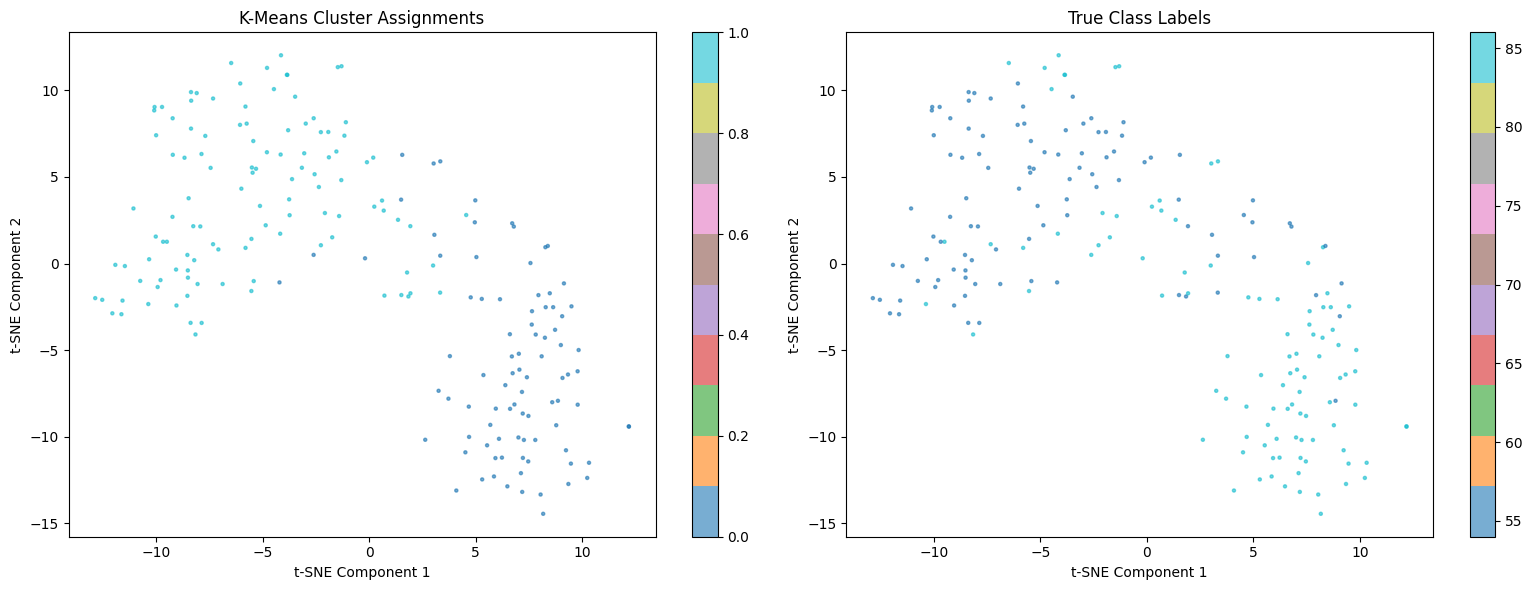

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


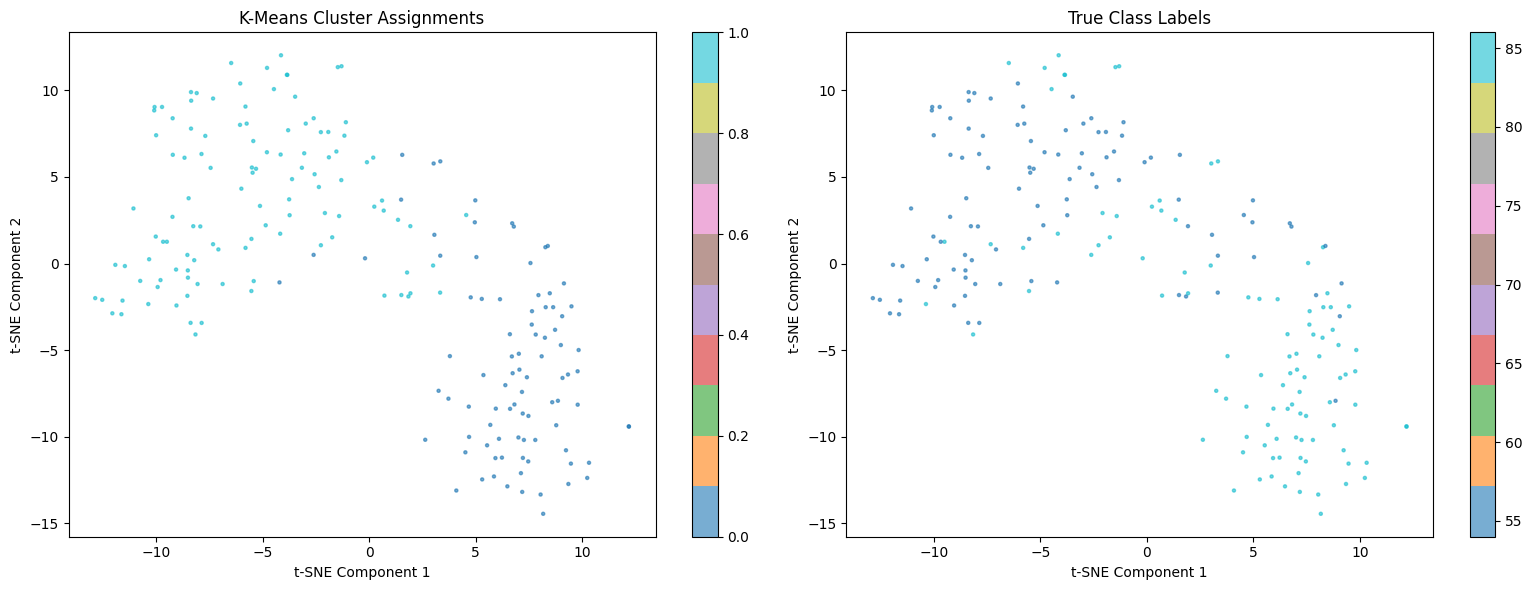


Analiza składu klastrów dla modelu 5...
Klaster 0 (rozmiar: 88):
  Klasa 86:  73 obrazów ( 83.0%)
  Klasa 54:  15 obrazów ( 17.0%)

Klaster 1 (rozmiar: 112):
  Klasa 54:  85 obrazów ( 75.9%)
  Klasa 86:  27 obrazów ( 24.1%)


Wizualizacja próbek klastrów dla modelu 5...


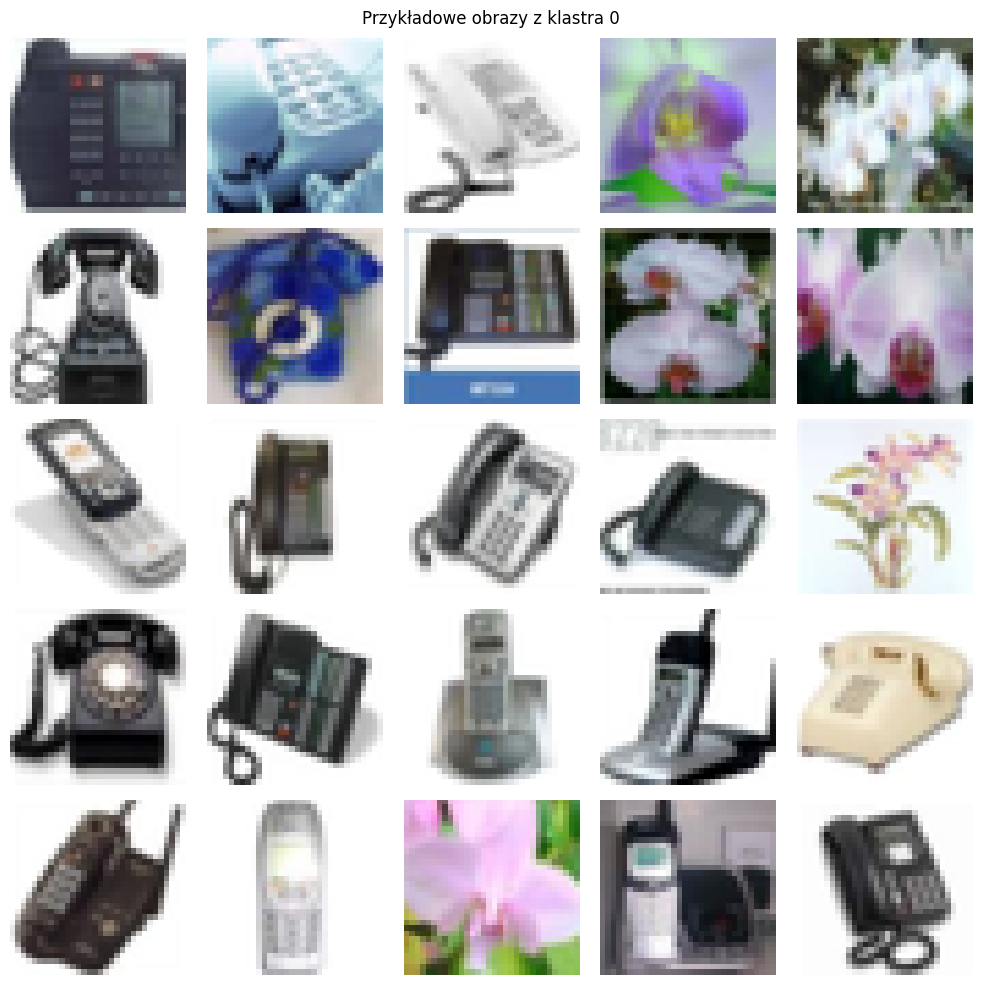


Czystość klastrów dla modelu 5...
Średnia czystość klastrów: 0.7942

Zakończono przetwarzanie modelu 5


Zapisywanie zbiorczych wyników...

PODSUMOWANIE WSZYSTKICH 5 MODELI (2 KLAS)
        nmi       ari  silhouette       dbi  n_clusters    inertia  model_id  n_classes    purity
0  0.596028  0.687342    0.142940  2.361227           2  96.853035         1          2  0.918389
1  0.007836  0.005289    0.104239  2.801990           2  92.666527         2          2  0.553056
2  0.261491  0.333070    0.143389  2.243386           2  84.875801         3          2  0.791868
3  0.125079  0.163902    0.123775  2.517522           2  82.284149         4          2  0.705185
4  0.265316  0.333097    0.194126  1.892518           2  83.428024         5          2  0.794237

STATYSTYKI
NMI - średnia: 0.2512, std: 0.2204
ARI - średnia: 0.3045, std: 0.2537
Silhouette - średnia: 0.1417, std: 0.0335
DBI - średnia: 2.3633, std: 0.3362
Inertia - średnia: 88.02, std: 6.39

Wszystkie wyniki zapisane w: C:\U

In [21]:
import os
import pandas as pd

# Konfiguracja - różne modele dla tej samej liczby klastrów
model_configs = [
    {'path': '../training_results/cmae/cifar100/2_classes_waga_01/cmae_cifar100_best_trening_1_20260122_120748.pt', 'n_clusters': 2, 'model_id': 1},
    {'path': '../training_results/cmae/cifar100/2_classes_waga_01/cmae_cifar100_best_trening_2_20260122_121300.pt', 'n_clusters': 2, 'model_id': 2},
    {'path': '../training_results/cmae/cifar100/2_classes_waga_01/cmae_cifar100_best_trening_3_20260122_122003.pt', 'n_clusters': 2, 'model_id': 3},
    {'path': '../training_results/cmae/cifar100/2_classes_waga_01/cmae_cifar100_best_trening_4_20260122_122614.pt', 'n_clusters': 2, 'model_id': 4},
    {'path': '../training_results/cmae/cifar100/2_classes_waga_01/cmae_cifar100_best_trening_5_20260122_123002.pt', 'n_clusters': 2, 'model_id': 5},
]

# Katalog do zapisu wyników
BASE_DIR = os.getcwd()
save_dir = os.path.join(BASE_DIR, '../..', 'experiments', 'cmae', 'cifar100', '2_classes_waga_01')
os.makedirs(save_dir, exist_ok=True)

# Batch size
batch_size = 64

# Lista do zbierania wszystkich wyników
all_results = []

# Pętla przez wszystkie modele
for config in model_configs:
    model_path = config['path']
    n_clusters = config['n_clusters']
    model_id = config['model_id']

    print(f"\n{'='*80}")
    print(f"Przetwarzanie modelu {model_id}/{len(model_configs)} dla {n_clusters} klas")
    print(f"{'='*80}\n")

    # Ładowanie modelu
    model, checkpoint = load_trained_model(model_path, model_type='cmae')
    selected_classes = checkpoint.get('selected_classes', None)

    # Ładowanie danych testowych
    _, _, _, _, test_loader = create_and_load_subset(
        n_clusters,
        batch_size=batch_size,
        seed=42,
        selected_classes=selected_classes
    )

    # Wyciąganie cech
    print(f"Wyciąganie cech dla modelu {model_id}...")
    features, labels = extract_features(model, test_loader)
    print(f"Unikalne etykiety: {np.unique(labels)}")

    # Klasteryzacja
    print(f"\nKlasteryzacja dla modelu {model_id}...")
    cluster_ids, kmeans, metrics = clustering(features, labels, n_clusters)

    # Dodanie informacji o modelu do metryk
    metrics['model_id'] = model_id
    metrics['n_classes'] = n_clusters
    all_results.append(metrics)

    # Zapis szczegółowych wyników klasteryzacji do CSV
    print(f"\nZapisywanie szczegółowych wyników klasteryzacji dla modelu {model_id}...")

    # Utworzenie DataFrame z wynikami klasteryzacji
    clustering_results = pd.DataFrame({
        'sample_id': range(len(cluster_ids)),
        'true_label': labels,
        'predicted_cluster': cluster_ids
    })

    # Zapis do pliku CSV
    clustering_csv_filename = f'clustering_assignments_{n_clusters}_classes_model_{model_id}.csv'
    clustering_csv_path = os.path.join(save_dir, clustering_csv_filename)
    clustering_results.to_csv(clustering_csv_path, index=False)
    print(f"Zapisano przypisania klastrów do: {clustering_csv_filename}")

    # Zapis metryk do osobnego CSV
    metrics_csv_filename = f'clustering_metrics_{n_clusters}_classes_model_{model_id}.csv'
    metrics_csv_path = os.path.join(save_dir, metrics_csv_filename)
    metrics_df = pd.DataFrame([metrics])
    metrics_df.to_csv(metrics_csv_path, index=False)
    print(f"Zapisano metryki do: {metrics_csv_filename}")

    # Opcjonalnie: jeśli funkcja save_results_to_csv zwraca results_df i summary_df
    # results_df, summary_df = save_results_to_csv(cluster_ids, labels, metrics, save_dir)

    # Wizualizacja PCA
    print(f"Generowanie wizualizacji PCA dla modelu {model_id}...")
    pca_filename = f'clusters_pca_{n_clusters}_classes_model_{model_id}'
    pca_path_png = os.path.join(save_dir, f'{pca_filename}.png')
    pca_path_eps = os.path.join(save_dir, f'{pca_filename}.eps')

    visualize_clusters(features, cluster_ids, labels, pca_path_png)
    visualize_clusters(features, cluster_ids, labels, pca_path_eps)

    # Wizualizacja t-SNE
    print(f"Generowanie wizualizacji t-SNE dla modelu {model_id}...")
    tsne_filename = f'clusters_tsne_{n_clusters}_classes_model_{model_id}'
    tsne_path_png = os.path.join(save_dir, f'{tsne_filename}.png')
    tsne_path_eps = os.path.join(save_dir, f'{tsne_filename}.eps')

    visualize_clusters_tsne(features, cluster_ids, labels, tsne_path_png)
    visualize_clusters_tsne(features, cluster_ids, labels, tsne_path_eps)

    # Dodatkowe analizy
    print(f"\nAnaliza składu klastrów dla modelu {model_id}...")
    analyze_cluster_composition(cluster_ids, labels, n_clusters)

    print(f"\nWizualizacja próbek klastrów dla modelu {model_id}...")
    visualize_cluster_samples(cluster_ids, test_loader, cluster_id=0, n_samples=25)

    print(f"\nCzystość klastrów dla modelu {model_id}...")
    purity = cluster_purity(cluster_ids, labels)

    # Dodanie purity do metryk jeśli funkcja zwraca wartość
    if purity is not None:
        metrics['purity'] = purity

    print(f"\n{'='*80}")
    print(f"Zakończono przetwarzanie modelu {model_id}")
    print(f"{'='*80}\n")

# Zapis zbiorczych wyników wszystkich modeli
print("\nZapisywanie zbiorczych wyników...")
summary_results_df = pd.DataFrame(all_results)
summary_csv_path = os.path.join(save_dir, f'all_models_summary_{n_clusters}_classes.csv')
summary_results_df.to_csv(summary_csv_path, index=False)

print("\n" + "="*80)
print(f"PODSUMOWANIE WSZYSTKICH {len(model_configs)} MODELI ({n_clusters} KLAS)")
print("="*80)
print(summary_results_df.to_string())

# Obliczenie statystyk
print("\n" + "="*80)
print("STATYSTYKI")
print("="*80)
print(f"NMI - średnia: {summary_results_df['nmi'].mean():.4f}, std: {summary_results_df['nmi'].std():.4f}")
print(f"ARI - średnia: {summary_results_df['ari'].mean():.4f}, std: {summary_results_df['ari'].std():.4f}")
print(f"Silhouette - średnia: {summary_results_df['silhouette'].mean():.4f}, std: {summary_results_df['silhouette'].std():.4f}")
print(f"DBI - średnia: {summary_results_df['dbi'].mean():.4f}, std: {summary_results_df['dbi'].std():.4f}")
print(f"Inertia - średnia: {summary_results_df['inertia'].mean():.2f}, std: {summary_results_df['inertia'].std():.2f}")

print(f"\nWszystkie wyniki zapisane w: {save_dir}")
print("="*80)